# Quench dynamics in spin chains — light cones, entanglement growth, relaxation

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 5 — Ground states and unitary dynamics*

## 1. Introduction and motivation

**The question.** Take a chain of interacting spins, prepare it in a simple state that you fully understand
(all spins up, say), and at time $t=0$ *suddenly* let it evolve under a Hamiltonian $H$ of which this state is **not** an
eigenstate. What happens next? This protocol is called a **quantum quench**, and it is the cleanest way
to study the dynamics of an isolated quantum many-body system:

* How fast can information and correlations travel through the chain? (There is no relativity in the Schrödinger
  equation of a spin chain — and yet we will see a *light cone*.)
* The evolution is unitary and the state stays pure forever, so in what sense can the system "relax"?
* Why does every classical algorithm eventually run out of steam when simulating such dynamics?

**Why people care.** For decades these were questions for theorists only, because a solid-state magnet is never
isolated: it exchanges energy with phonons long before anything interesting happens. This changed with *quantum simulators*:

* **ultracold atoms in optical lattices** — a laser intensity or a magnetic field is switched in microseconds, the system stays
  isolated for seconds. Landmark experiments: the "quantum Newton's cradle", a nearly integrable gas that keeps the memory of its initial
  momentum distribution through thousands of collisions (Kinoshita *et al.* 2006), the direct observation of light-cone spreading of
  correlations (Cheneau *et al.* 2012), and the measurement of the entanglement entropy of a many-body state by interfering two copies
  of it (Islam *et al.* 2015);
* **trapped ions** — chains of 10–50 ions realise Ising models with tunable range; a quench is a sudden switch-on of laser-mediated
  couplings (Richerme *et al.* 2014, Jurcevic *et al.* 2014, 2017);
* **Rydberg-atom arrays** — tens to hundreds of atoms in optical tweezers, initialised in a product state and released into
  Ising-type dynamics (Bernien *et al.* 2017);
* **superconducting qubits** — the same dynamics run as a Trotter circuit, gate by gate.

In all these platforms the experimental protocol is *literally* the numerical protocol of this notebook:
prepare a product state → evolve with $H$ → measure local observables and correlations. Simulations like ours are
used to benchmark the devices at small sizes — and the devices are interesting precisely because simulations fail at large sizes.
We will see *why* they fail: entanglement.

**What we will compute.** This is the physics showcase of Chapter 5. The integrators themselves were derived in the previous
notebooks; here we use them as trusted tools (after re-validating them — never trust a simulator you have not tested):

| Section | Experiment | Physics |
|---|---|---|
| 3–4 | toolbox + validation against exact evolution, integrator cross-checks | how much Trotter error can we afford? |
| 5 | quench of an XXZ chain in a transverse field from $\vert\!\uparrow\uparrow\dots\uparrow\rangle$ | relaxation of magnetisation and correlators, entanglement, delocalisation in Hilbert space |
| 6 | transverse-field Ising chain | Lieb–Robinson light cone of correlations |
| 7 | XXZ chain from a domain wall $\vert\!\uparrow\uparrow\uparrow\downarrow\downarrow\downarrow\rangle$ | ballistic vs. slow vs. frozen spin transport, free-fermion check |
| 8 | tilted-field Ising chain, integrable vs. non-integrable | linear entanglement growth, Page saturation, relaxation of a local observable — and why classical simulation dies |
| 9 | Loschmidt echo after an Ising quench | return probability, dynamical quantum phase transitions |
| 10 | performance | cost $O(N\,2^N)$ per step, compile vs. run time |

### What you will learn

*Physics*

* what a quantum quench is, and how dephasing between energy eigenstates produces relaxation in a closed system;
* Lieb–Robinson bounds and the quasiparticle picture of light cones and of linear entanglement growth;
* integrable (free-fermion, Bethe-ansatz) versus generic chains: transport, relaxation of local observables, entanglement saturation;
* the Loschmidt echo and dynamical quantum phase transitions.

*Numerical methods*

* how to organise a time-dependent simulation: evolve — observe — evolve — observe;
* choosing the Trotter step from a measured error budget; cross-validating integrators (TEBD, Chebyshev, Krylov, exact);
* cheap observables: everything diagonal from $|\psi|^2$, everything about a bipartition from one SVD;
* independent checks from physics: conservation laws, short-time expansions, free-fermion solutions.

*Implementation practice*

* `lax.scan` inside `lax.scan` (many cheap steps per expensive measurement), observables returned as a *pytree* (a dict of arrays);
* `jax.vmap` over Hamiltonian parameters (a traced coupling inside the gate exponentials) and over initial states;
* `jax.vmap` over time to build an exact reference trajectory; honest timing with compile and run time separated.

### Prerequisites
* [Matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) — states as rank-$N$ tensors, `apply_gate`;
* [States, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb) — reduced density matrices, Schmidt decomposition, entanglement entropy;
* [TEBD / Trotter–Suzuki](12_tebd_trotter_suzuki.ipynb), [Chebyshev propagation](13_chebyshev_propagation.ipynb),
  [Krylov propagation and the integrator comparison](14_krylov_and_integrator_comparison.ipynb) — the integrators used here;
* [JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) — `jit`, `vmap`, `lax.scan`.

Units: $\hbar = 1$, energies in units of the exchange coupling $J$, times in units of $1/J$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Theory: what happens after a quench

### 2.1 The protocol

1. Prepare $|\psi_0\rangle$. In experiments this is a state that can be made with high fidelity: a **product state**
   (all spins polarised, a Néel pattern $|\!\uparrow\downarrow\uparrow\downarrow\dots\rangle$, a domain wall), or the ground state of a simple *pre-quench* Hamiltonian $H_0$.
2. At $t=0$ change the Hamiltonian abruptly, $H_0 \to H$. "Abruptly" means faster than any internal time scale $1/J$, so the state has no time to follow.
3. Let the isolated system evolve, $|\psi(t)\rangle = e^{-iHt}|\psi_0\rangle$, and measure.

### 2.2 Relaxation in a closed system: dephasing

Expand the initial state in the eigenbasis of the *post-quench* Hamiltonian, $H|n\rangle = E_n|n\rangle$, $c_n = \langle n|\psi_0\rangle$:

$$ |\psi(t)\rangle = \sum_n c_n\, e^{-iE_n t}\,|n\rangle . $$

The expectation value of an observable $O$ with matrix elements $O_{mn} = \langle m|O|n\rangle$ is then

$$ \langle O(t)\rangle = \underbrace{\sum_n |c_n|^2\, O_{nn}}_{\text{time independent}} \;+\; \sum_{m\neq n} c_m^* c_n\, e^{\,i(E_m-E_n)t}\, O_{mn}. \qquad (1)$$

Nothing in Eq. (1) decays — every term oscillates forever. But a many-body state overlaps with *exponentially many* eigenstates, and
the $\sim 4^N$ frequencies $E_m-E_n$ are incommensurate. After a short time the phases are effectively random, the second sum averages to
(almost) zero, and the observable settles to the first sum, the **diagonal ensemble**. *Relaxation of a closed quantum system is dephasing.*
In a small system the cancellation is imperfect (we will see fluctuations that shrink with $N$), and after a very long time the phases can re-align (revivals).

What is conserved: the energy $E=\langle\psi_0|H|\psi_0\rangle$ — and in fact every $|c_n|^2$. A quench from a product state injects an
*extensive* amount of energy above the ground state ($E - E_{\rm gs} \propto N$): we are probing the middle of the many-body spectrum, not the low-energy physics of notebook
[Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb).

> **Physics insight.** By Eq. (1) the long-time value of an observable is fixed by the weights $|c_n|^2$, i.e. by what the initial state and $H$ have in
> common. How much of the initial state survives in these weights depends on $H$. A generic ("non-integrable") Hamiltonian conserves little besides the
> energy, and the local observables of initial states with the same energy relax to nearly the same stationary values. *Integrable* models — models with an
> extensive number of local conservation laws $Q_\alpha$, such as free fermions or Bethe-ansatz solvable chains — keep much more memory: every
> $\langle Q_\alpha\rangle$ is fixed by the initial state, and the stationary values of local observables depend on all of them (Essler & Fagotti 2016).
> We will meet both kinds.

### 2.3 The models

All Hamiltonians are nearest-neighbour open chains in the Pauli convention of the course
($X_j, Y_j, Z_j$ are Pauli matrices on site $j$; $|\!\uparrow\rangle \equiv |0\rangle$ is the $+1$ eigenstate of $Z$):

$$ H = \sum_{j=0}^{N-2}\big(J_{xx} X_jX_{j+1} + J_{yy} Y_jY_{j+1} + J_{zz} Z_jZ_{j+1}\big) + \sum_{j=0}^{N-1}\big(h_x X_j + h_z Z_j\big). \qquad (2)$$

| name | couplings in Eq. (2) | character | used in |
|---|---|---|---|
| XXZ chain in a transverse field | $J_{xx}=J_{yy}=1,\ J_{zz}=0.5,\ h_x=1$ | generic (no known exact solution); the field breaks the conservation of $\sum_j Z_j$ | §4, §5 |
| transverse-field Ising (TFIM) | $J_{zz}=-J,\ h_x=-h$ | integrable: maps to free fermions | §6, §9 |
| XXZ chain | $J_{xx}=J_{yy}=J,\ J_{zz}=J\Delta$ | integrable (Bethe ansatz); conserves $\sum_j Z_j$; $\Delta=0$: free fermions, $\Delta=1$: Heisenberg | §7 |
| tilted-field Ising | $J_{zz}=J,\ h_x=g,\ h_z$ | non-integrable for $h_z\neq0$, integrable TFIM for $h_z=0$ | §8 |

### 2.4 The observables

| symbol | definition | what it tells us |
|---|---|---|
| $\langle X_j\rangle,\langle Y_j\rangle,\langle Z_j\rangle$ | local Bloch vector | magnetisation dynamics — what a quantum-gas microscope or ion camera sees |
| $\langle X_jX_{j+1}\rangle$, $\langle Y_jY_{j+1}\rangle$, $\langle Z_jZ_{j+1}\rangle$ | nearest-neighbour correlators | the bond energies; together with the fields they give $E(t)$ |
| $C_{ij}=\langle Z_iZ_j\rangle-\langle Z_i\rangle\langle Z_j\rangle$ | connected correlation | zero for product states; its spreading defines the light cone |
| $S_A = -\sum_k p_k\log_2 p_k$ | half-chain entanglement entropy from the Schmidt weights $p_k=\lambda_k^2$ | the cost of any classical (tensor-network) description |
| $\mathcal N,\ E_{\mathcal N}$ | negativity and logarithmic negativity (§3.3) | an entanglement measure that also works for mixed states |
| ${\rm IPR}=\sum_s \lvert\psi_s\rvert^4$ | inverse participation ratio in the computational basis | 1 for a basis state, $\approx 2/2^N$ for a random state: spreading over Hilbert space |
| $\mathcal L(t)=\lvert\langle\psi_0\vert\psi(t)\rangle\rvert^2$ | Loschmidt echo (return probability) | how fast the state becomes orthogonal to where it started |

### 2.5 Three time scales of a finite open chain

Every statement we will test is a statement about the *infinite* chain, and every simulation runs on $N\le16$ sites with open ends. Three
time scales separate what the data mean, all of them set by the maximal group velocity $v_{\max}$ of the excitations (§6.2):

1. **Reflection.** An excitation emitted at site $j$ reaches the nearer chain end after $t_{\rm edge}=d_{\rm end}/v_{\max}$ and bounces back
   (open ends are perfect mirrors: nothing leaves the chain). A correlation front, built from *pairs*, sweeps the chain twice as fast, so
   connected correlations feel the ends already at $t_{\rm edge}/2$. Beyond that time the profiles are those of a finite box, not of a chain.
2. **Saturation of the half-chain entropy** at $t_{\rm sat}\simeq (N/2)/v_{\max}=N/(2v_{\max})$ — the time a quasiparticle emitted at the far
   end of one half needs to reach the cut (§8.1). Before $t_{\rm sat}$ all system sizes must lie on top of each other; after it the plateau
   is a finite-size number.
3. **Revivals and recurrences.** Reflected quasiparticles re-focus, so local observables show partial revivals on the scale $t\sim N/v_{\max}$;
   they are strong in integrable chains, where the quasiparticles keep their identity, and weak in generic ones, where they scatter. A *full*
   Poincaré recurrence of the state needs a time exponentially long in $N$ and is never reached here.

Read as a rule: **the window in which a finite chain imitates an infinite one is $t\lesssim t_{\rm edge}$**, and every plot in this notebook that
extends beyond it does so deliberately — §8 wants the plateau, §9 wants many critical times. The concrete numbers ($v_{\max}=2\min(J,h)$ for the
Ising chains, $4J$ for the $XX$ chain) are collected with each experiment.

## 3. The toolbox

### 3.1 Engine recap

The next (folded) cell contains the simulator primitives used in this notebook, verbatim from the course engine: `apply_gate` (one einsum per
local operator), `heisenberg_terms` (the Hamiltonian as a list of local terms), `tebd_gates` (one Trotter–Suzuki step as a gate list),
the reference integrators `chebyshev_evolve`, `krylov_evolve`, and the dense `dense_hamiltonian` used **only** for validation at small $N$.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for any product PP of two Pauli matrices (XX, YY, ZZ, XY, ...).

    Because (P x Q)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rxx(theta):
    """exp(-i theta X(x)X / 2)."""
    return rpp(theta, XX)

def ryy(theta):
    """exp(-i theta Y(x)Y / 2)."""
    return rpp(theta, YY)

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def all_local_expectations(psi):
    """Bloch vectors of all qubits: array (N,3) with rows (<X_q>, <Y_q>, <Z_q>), from the 1-qubit RDMs."""
    out = []
    for q in range(psi.ndim):
        r = rdm(psi, [q])
        out.append(jnp.stack([jnp.real(jnp.trace(r @ P)) for P in (X, Y, Z)]))
    return jnp.stack(out)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def spectral_bounds(terms, N, m=40, key=None):
    """Cheap estimate of (E_min, E_max) from a short Lanczos run -- needed to rescale H into [-1,1]
    for the Chebyshev expansion."""
    key = jax.random.PRNGKey(1) if key is None else key
    a, b, _ = lanczos(jax.jit(lambda p: apply_hamiltonian(terms, p)), haar_state(key, N), m)
    w = np.linalg.eigvalsh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
    return float(w[0]), float(w[-1])

def chebyshev_evolve(psi, terms, t, bounds, tol=1e-13, safety=1.02):
    """exp(-iHt)|psi> by Chebyshev expansion (Tal-Ezer & Kosloff) -- no Trotter error.

    MATH   rescale  Ht = (H - b)/a  with a = (Emax-Emin)/2, b = (Emax+Emin)/2   => spectrum in [-1,1]
           Jacobi-Anger:   e^{-i a t x} = sum_k (2 - delta_k0) (-i)^k J_k(a t) T_k(x)
           =>  e^{-iHt}|psi> = e^{-i b t} sum_k c_k |phi_k>,    c_k = (2-delta_k0)(-i)^k J_k(a t)
           recurrence     |phi_0> = |psi>, |phi_1> = Ht|psi>, |phi_{k+1}> = 2 Ht|phi_k> - |phi_{k-1}>.
    CONVERGENCE   J_k(at) decays super-exponentially for k > a t: the number of terms is ~ a t + O(10),
           and the error can be pushed to machine precision.  Memory: 3 vectors.
    JAX    the recurrence is a `lax.scan` whose carry is (phi_{k-1}, phi_k, accumulated sum).
    """
    from scipy.special import jv
    Emin, Emax = bounds
    a, b = safety * (Emax - Emin) / 2.0, (Emax + Emin) / 2.0
    K = int(np.ceil(a * abs(t))) + 20
    while abs(jv(K, a * t)) > tol:
        K += 10
    coef = jnp.asarray([(1 if k == 0 else 2) * ((-1j) ** k) * jv(k, a * t) for k in range(K + 1)], dtype=CDTYPE)

    def Ht(p):
        return (apply_hamiltonian(terms, p) - b * p) / a

    T0, T1 = psi, Ht(psi)
    acc0 = coef[0] * T0 + coef[1] * T1

    def body(carry, c):
        Tm, Tc, acc = carry
        Tn = 2 * Ht(Tc) - Tm
        return (Tc, Tn, acc + c * Tn), None

    (_, _, acc), _ = lax.scan(body, (T0, T1, acc0), coef[2:])
    return jnp.exp(-1j * b * t) * acc

def krylov_evolve(psi, terms, t, m=30):
    """exp(-iHt)|psi> in an m-dimensional Krylov space:
        |psi(t)> ~ ||psi|| * V exp(-i T t) e_1 ,      T = V^dag H V  (tridiagonal, from Lanczos).
    Exact for polynomials of degree < m in H; accurate as long as  |t| * (spectral width)  <~  m.
    For long times: chain several short Krylov steps."""
    nrm = jnp.linalg.norm(psi)
    a, b, V = lanczos(jax.jit(lambda p: apply_hamiltonian(terms, p)), psi, m)
    w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
    c = S_ @ (np.exp(-1j * t * w) * S_[0, :])
    return nrm * jnp.tensordot(jnp.asarray(c, dtype=CDTYPE), V, axes=1)


### 3.2 Evolve — observe — evolve — observe: a scan inside a scan

A quench simulation is a loop over time steps. Two facts shape its implementation:

* the Trotter step $\delta t$ must be small for accuracy (we will use $\delta t = 0.02$), but observables are smooth on that scale —
  it is enough to measure every $n_{\rm sub}$-th step. This matters, because some measurements (an SVD for the entanglement entropy) cost more than a step;
* a Python `for` loop under `jax.jit` would be *unrolled*: 250 steps $\times$ 50 gates $=12\,500$ einsums in one giant program that takes forever to compile.

`lax.scan(f, carry, xs, length)` is JAX's compiled loop: `f(carry, x) -> (new_carry, output)` is traced **once**, the loop runs inside XLA, and the
outputs are stacked along a new leading (time) axis. We nest two scans:

```
outer scan, n_meas iterations:   psi -> [ inner scan, n_sub iterations: psi -> one TEBD step ] -> observe(psi)
```

`observe` may return any *pytree* — we use a dict of arrays — and `scan` stacks each leaf separately: a dict entry of shape `(N, 3)` comes back as
`(n_meas, N, 3)`. (See [JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) for `scan` and pytrees.)

In [3]:
# ==============================================================================
# STEP 1: the time loop -- evolve with a fixed gate list, observe every n_sub steps
# ==============================================================================
def evolve_and_observe(psi0, gates, n_meas, n_sub, observe):
    """Evolve `psi0` for n_meas*n_sub Trotter steps and record `observe(psi)` at t = 0 and after
    every n_sub steps.

    MATH   psi(t_k) = [U(dt)]^{k n_sub} psi0,   t_k = k n_sub dt,   k = 0..n_meas,
           with U(dt) the product of the local gates in `gates` (one Trotter-Suzuki step).
    IMPLEMENTATION   inner scan = n_sub steps (no output), outer scan = measurements.
           The t=0 measurement is prepended with `tree_map`, which applies a function to every
           leaf of the observable pytree (here: concatenate along the time axis).
    COST   n_meas*n_sub * len(gates) einsums of O(2^N) each + n_meas calls of `observe`.
    JAX    fully traceable: wrap the caller in jax.jit; vmap over psi0 or over Hamiltonian
           parameters hidden in `gates` works out of the box.
    Returns (psi_final, obs) where every leaf of obs has leading dimension n_meas+1.
    """
    def one_step(psi, _):
        return apply_gates(psi, gates), None

    def one_block(psi, _):
        psi, _ = lax.scan(one_step, psi, None, length=n_sub)
        return psi, observe(psi)

    psi_final, obs = lax.scan(one_block, psi0, None, length=n_meas)
    obs0 = observe(psi0)
    obs = jax.tree_util.tree_map(lambda first, rest: jnp.concatenate([first[None], rest]), obs0, obs)
    return psi_final, obs

### 3.3 Observables that cost (almost) nothing

**Local Bloch vectors and bond correlators.** $\langle O\rangle = {\rm Tr}(\rho_A O)$ with the reduced density matrix of the one or two sites involved
(engine functions `rdm`, `all_local_expectations`). One $4\times4$ matrix $\rho_{j,j+1}$ delivers $\langle XX\rangle,\langle YY\rangle,\langle ZZ\rangle$ at once.

**Everything diagonal from the probabilities.** $Z$-type observables only need $p(s) = |\psi(s)|^2$, which is a real rank-$N$ tensor:

$$\langle Z_q\rangle = \sum_{s} p(s)\,(-1)^{s_q}, \qquad \langle Z_cZ_j\rangle = \sum_{s} p(s)\,(-1)^{s_c}(-1)^{s_j}.$$

With the sign vector $z=(+1,-1)$ these are einsums in which **every** index is summed: for $N=4$, $q=1$: `"abcd,b->"`, and for the pair $(c,j)=(1,3)$: `"abcd,b,d->"`.

**Everything about the half-chain cut from one SVD.** Reshape the state tensor into a $2^{N/2}\times2^{N/2}$ matrix (left half = row index); its singular values
$\lambda_k$ are the Schmidt coefficients, $|\psi\rangle=\sum_k\lambda_k|u_k\rangle_A|v_k\rangle_B$ (derived in
[States, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb)). Then

* entanglement entropy $S_A=-\sum_k\lambda_k^2\log_2\lambda_k^2$ (in bits);
* **negativity.** For a mixed state, the negativity is $\mathcal N=\sum(\text{absolute values of the negative eigenvalues of }\rho^{T_A})$, where $T_A$ is the partial transpose on $A$ (Vidal & Werner 2002).
  For a pure state in Schmidt form, $\rho=\sum_{kl}\lambda_k\lambda_l\,|u_k\rangle\langle u_l|\otimes|v_k\rangle\langle v_l|$, and transposing only the $A$ factor
  ($(|u_k\rangle\langle u_l|)^{T}=|u_l^{*}\rangle\langle u_k^{*}|$, where $|u^*\rangle$ has the complex-conjugated components) gives
  $\rho^{T_A}=\sum_{kl}\lambda_k\lambda_l\,|u_l^{*}\rangle\langle u_k^{*}|\otimes|v_k\rangle\langle v_l|$. Acting with it on $|u_m^{*}\rangle|v_n\rangle$ leaves only the terms $k=m$, $l=n$ and returns
  $\lambda_m\lambda_n|u_n^{*}\rangle|v_m\rangle$: the pair $(m,n)$ is *swapped*. Hence the eigenvectors are
  $|u_k^*v_k\rangle$ with eigenvalue $\lambda_k^2$, and $(|u_k^*v_l\rangle\pm|u_l^*v_k\rangle)/\sqrt2$ with eigenvalues $\pm\lambda_k\lambda_l$ for $k<l$. The negative ones sum to

  $$\mathcal N=\sum_{k<l}\lambda_k\lambda_l=\frac{(\sum_k\lambda_k)^2-\sum_k\lambda_k^2}{2}=\frac{(\sum_k\lambda_k)^2-1}{2},\qquad E_{\mathcal N}=\log_2(2\mathcal N+1)=2\log_2\sum_k\lambda_k .$$

  No $4^N$-sized density matrix is needed. ($E_{\mathcal N}$ of a pure state is its Rényi-$\tfrac12$ entropy, hence $E_{\mathcal N}\ge S_A$.)

We return the *Schmidt values themselves* from the time loop and post-process them; this also gives us the entanglement spectrum for §8.

In [4]:
# ==============================================================================
# STEP 2: observables (all matrix-free, all jit/vmap/scan compatible)
# ==============================================================================
Z_SIGNS = jnp.array([1.0, -1.0], dtype=RDTYPE)          # eigenvalues of Z for s = 0 (up), 1 (down)


def z_profile(psi):
    """Magnetisation profile <Z_q>, q = 0..N-1, from the probabilities p = |psi|^2.

    MATH    <Z_q> = sum_s p(s) (-1)^{s_q}
    EINSUM  N=4, q=1:  "abcd,b->"   (operands p, z) -- no index survives: a full contraction to a scalar.
    COST    O(2^N) per site.
    """
    N = psi.ndim
    p = jnp.abs(psi) ** 2
    letters = _LETTERS[:N]
    return jnp.stack([jnp.einsum(f"{letters},{letters[q]}->", p, Z_SIGNS) for q in range(N)])


def zz_connected_row(psi, c):
    """Connected correlations C_{cj} = <Z_c Z_j> - <Z_c><Z_j> of site c with all sites j (C_cc = 1 - <Z_c>^2).

    EINSUM  N=4, (c,j)=(1,3):  "abcd,b,d->"  with operands p, z, z.
    """
    N = psi.ndim
    p = jnp.abs(psi) ** 2
    letters = _LETTERS[:N]
    m = z_profile(psi)
    zz = [jnp.einsum(f"{letters},{letters[c]},{letters[j]}->", p, Z_SIGNS, Z_SIGNS) if j != c
          else jnp.asarray(1.0, dtype=RDTYPE) for j in range(N)]
    return jnp.stack(zz) - m[c] * m


def bond_correlators(psi):
    """Nearest-neighbour correlators: array (N-1, 3) with rows (<X_j X_j+1>, <Y_j Y_j+1>, <Z_j Z_j+1>).
    One 4x4 reduced density matrix per bond serves all three:  <PP> = Tr(rho_{j,j+1} P(x)P)."""
    N = psi.ndim
    rows = []
    for j in range(N - 1):
        r = rdm(psi, (j, j + 1))
        rows.append(jnp.stack([jnp.real(jnp.trace(r @ PP)) for PP in (XX, YY, ZZ)]))
    return jnp.stack(rows)


def half_chain_schmidt(psi):
    """Schmidt values lambda_k of the cut between sites N/2-1 and N/2 (one SVD of a 2^{N/2} x 2^{N/2} matrix)."""
    return schmidt_values(psi, tuple(range(psi.ndim // 2)))


def entropy_from_schmidt(lam):
    """S = -sum_k p_k log2 p_k,  p_k = lambda_k^2  (bits).  Clipping implements 0*log 0 = 0."""
    p = jnp.clip(lam ** 2, 1e-30, None)
    return -jnp.sum(p * jnp.log2(p), axis=-1)


def negativity_from_schmidt(lam):
    """Pure-state negativity  N = ((sum_k lambda_k)^2 - 1)/2   (see the derivation above)."""
    return (jnp.sum(lam, axis=-1) ** 2 - 1.0) / 2.0


def observe_everything(psi, psi0):
    """The full measurement record of one snapshot, as a dict (a pytree -> scan stacks every entry)."""
    return dict(bloch=all_local_expectations(psi),            # (N, 3)   <X_j>, <Y_j>, <Z_j>
                bonds=bond_correlators(psi),                   # (N-1, 3) <XX>, <YY>, <ZZ> on every bond
                schmidt=half_chain_schmidt(psi),               # (2^{N/2},)
                ipr=jnp.sum(jnp.abs(psi) ** 4),                # inverse participation ratio
                norm=jnp.linalg.norm(psi),                     # must stay 1: every Trotter gate is unitary
                echo=jnp.abs(jnp.vdot(psi0, psi)) ** 2)        # Loschmidt echo |<psi0|psi(t)>|^2

A two-line sanity check of the entanglement formulas on a state we know by heart: the Bell pair $(|00\rangle+|11\rangle)/\sqrt2$ has $\lambda=(1,1)/\sqrt2$,
hence $S=1$ bit, $\mathcal N=\tfrac12$, $E_{\mathcal N}=1$; a product state has $S=\mathcal N=0$. We also test the diagonal-observable einsums against the generic RDM route.

In [5]:
# ==============================================================================
# CHECKPOINT 0: observables on states with known answers
# ==============================================================================
bell = (basis_state([0, 0]) + basis_state([1, 1])) / jnp.sqrt(2.0)
lam = half_chain_schmidt(bell)
print(f"Bell pair   : S = {float(entropy_from_schmidt(lam)):.6f} bit,  negativity = {float(negativity_from_schmidt(lam)):.6f}")
assert abs(float(entropy_from_schmidt(lam)) - 1.0) < TOL and abs(float(negativity_from_schmidt(lam)) - 0.5) < TOL
lam = half_chain_schmidt(product_state("0+1-"))
print(f"product     : S = {float(entropy_from_schmidt(lam)):.2e} bit,  negativity = {float(negativity_from_schmidt(lam)):.2e}")
assert abs(float(entropy_from_schmidt(lam))) < TOL and abs(float(negativity_from_schmidt(lam))) < 10 * TOL

# diagonal einsums vs reduced density matrices on a random 6-spin state
key = jax.random.PRNGKey(2024)
k1, k2 = jax.random.split(key)
phi = jax.random.normal(k1, (2,) * 6) + 1j * jax.random.normal(k2, (2,) * 6)
phi = (phi / jnp.linalg.norm(phi)).astype(CDTYPE)
err_z = float(jnp.max(jnp.abs(z_profile(phi) - all_local_expectations(phi)[:, 2])))
ref = jnp.stack([expect_local(phi, ZZ, (2, j)) - expect_local(phi, Z, (2,)) * expect_local(phi, Z, (j,))
                 for j in range(6) if j != 2])
got = jnp.stack([zz_connected_row(phi, 2)[j] for j in range(6) if j != 2])
err_zz = float(jnp.max(jnp.abs(ref - got)))
print(f"random state: max |<Z_q> einsum - RDM| = {err_z:.1e},   max |C_2j einsum - RDM| = {err_zz:.1e}")
assert err_z < TOL and err_zz < TOL

Bell pair   : S = 1.000000 bit,  negativity = 0.500000


product     : S = 6.41e-16 bit,  negativity = -1.11e-16


random state: max |<Z_q> einsum - RDM| = 2.8e-16,   max |C_2j einsum - RDM| = 1.1e-16


All four numbers agree with the analytic values and the two independent routes to $\langle Z\rangle$, $C_{ij}$ coincide to round-off. The toolbox is ready.

### 3.4 An exact reference trajectory (small $N$ only)

For validation we want $|\psi(t_k)\rangle$ at *all* measurement times from dense linear algebra. Diagonalise once, $H=V\,{\rm diag}(E)\,V^\dagger$, then

$$|\psi(t)\rangle = V\,e^{-iEt}\,\underbrace{V^\dagger|\psi_0\rangle}_{c}\quad\Longrightarrow\quad \Psi_{t,i}=\sum_n V_{in}\,e^{-iE_nt}\,c_n ,\qquad\texttt{einsum("in,tn->ti", V, phases*c)} .$$

Cost $O(8^N)$ for the diagonalisation and $O(4^N)$ memory — this is the wall the matrix-free methods avoid; we use it up to $N=10$ ($1024\times1024$).
The observables of all snapshots then follow from a single `jax.vmap` of the *same* `observe` function over the time axis.

In [6]:
# ==============================================================================
# STEP 3: dense reference -- VALIDATION ONLY (builds the 2^N x 2^N matrix)
# ==============================================================================
def exact_trajectory(psi0, terms, times):
    """States psi(t) for all t in `times` by full diagonalisation.  Returns an array (len(times), 2,..,2).

    MATH   psi(t) = V exp(-i E t) V^dag psi0
    COST   O(8^N) time, O(4^N) memory -> small N only.
    """
    N = psi0.ndim
    E, V = jnp.linalg.eigh(dense_hamiltonian(terms, N))
    c = V.conj().T @ psi0.reshape(-1)                                    # amplitudes c_n = <n|psi0>
    phases = jnp.exp(-1j * jnp.asarray(times, dtype=RDTYPE)[:, None] * E[None, :])  # (T, 2^N)
    flat = jnp.einsum("in,tn->ti", V, phases * c[None, :])
    return flat.reshape((len(times),) + (2,) * N)

## 4. Checkpoint: the affordable Trotter error

**Model and protocol** (row 1 of the table in §2.3): $J_{xx}=J_{yy}=1$, $J_{zz}=0.5$, $h_x=1$, initial state $|\!\uparrow\uparrow\dots\uparrow\rangle=|00\dots0\rangle$,
evolution to $T=5$ with $\delta t=0.02$ (250 steps), a snapshot every 5 steps.

We run TEBD of order 1, 2 and 4 at $N=10$ and compare with the exact trajectory through

* the **infidelity** $1-F(t)$, $F=|\langle\psi_{\rm exact}(t)|\psi_{\rm TEBD}(t)\rangle|^2$ — the strictest test, sensitive to every amplitude and phase;
* the **root-mean-square deviation of all $6N-3$ local observables** — what actually matters for the physics plots.

Recall from [TEBD / Trotter–Suzuki](12_tebd_trotter_suzuki.ipynb): a $p$-th order step has a *state* error that accumulates as $\epsilon(t)\sim C\,t\,\delta t^{\,p}$, so the
infidelity behaves as $1-F\sim\epsilon^2\propto t^2\,\delta t^{\,2p}$.

> **Physics insight.** On one bond the three terms $X\!X$, $Y\!Y$, $Z\!Z$ **commute** (each pair of them anticommutes on site $j$ *and* on site $j+1$, two minus signs cancel). Hence
> $e^{-i(J_{xx}XX+J_{yy}YY+J_{zz}ZZ)\delta t}=R_{xx}(2J_{xx}\delta t)\,R_{yy}(2J_{yy}\delta t)\,R_{zz}(2J_{zz}\delta t)$ *exactly*: our single $4\times4$ bond gate is what a trapped-ion or
> superconducting device would run as three native two-qubit rotations — $3(N-1)+N=4N-3$ hardware gates per first-order step. The Trotter error comes only from
> *neighbouring bonds* and from the field, which do not commute. The next cell verifies the identity.

In [7]:
# ==============================================================================
# PARAMETERS of the reference quench  (change them and re-run the notebook)
# ==============================================================================
JXX, JYY, JZZ, HX = 1.0, 1.0, 0.5, 1.0     # XXZ couplings + transverse field
T_MAX, DT, N_SUB = 5.0, 0.02, 5            # final time, Trotter step, steps per snapshot
N_MEAS = int(round(T_MAX / (DT * N_SUB)))  # number of snapshots after t=0
times = np.arange(N_MEAS + 1) * DT * N_SUB
N_CHECK = 10                               # validation size (dense 1024 x 1024)

# the bond gate as three commuting native rotations  (rpp(theta) = exp(-i theta PP / 2))
bond_gate = tebd_gates(heisenberg_terms(2, JXX, JYY, JZZ), DT, order=1)[0][1]
native = rxx(2 * JXX * DT) @ ryy(2 * JYY * DT) @ rzz(2 * JZZ * DT)
err = float(jnp.max(jnp.abs(bond_gate - native)))
print(f"|exp(-i h_bond dt) - Rxx Ryy Rzz| = {err:.1e}")
assert err < TOL

|exp(-i h_bond dt) - Rxx Ryy Rzz| = 1.1e-16


In [8]:
# ==============================================================================
# CHECKPOINT 1: TEBD orders 1, 2, 4 against the exact trajectory (N = 10)
# ==============================================================================
terms = heisenberg_terms(N_CHECK, JXX, JYY, JZZ, hx=HX)
psi0 = zero_state(N_CHECK)

t0 = time.time()
traj_exact = exact_trajectory(psi0, terms, times)
traj_exact.block_until_ready()
t_exact = time.time() - t0

observe_all_times = jax.jit(jax.vmap(lambda psi: observe_everything(psi, psi0)))   # vmap over the time axis
obs_exact = observe_all_times(traj_exact)


def flat_observables(obs):
    """All local observables of all snapshots as one array (T, 6N-3): used for the RMS deviation."""
    T = obs["bloch"].shape[0]
    return jnp.concatenate([obs["bloch"].reshape(T, -1), obs["bonds"].reshape(T, -1)], axis=1)


check = {}
for order in (1, 2, 4):
    gates = tebd_gates(terms, DT, order)
    run = jax.jit(lambda p, gates=gates: evolve_and_observe(p, gates, N_MEAS, N_SUB, lambda s: s))  # record the states
    t0 = time.time()
    _, traj = run(psi0)
    traj.block_until_ready()
    wall = time.time() - t0
    infid = 1.0 - jax.vmap(fidelity_pure)(traj_exact, traj)
    obs = observe_all_times(traj)
    rmse = jnp.sqrt(jnp.mean((flat_observables(obs) - flat_observables(obs_exact)) ** 2, axis=1))
    check[order] = dict(infid=np.asarray(infid), rmse=np.asarray(rmse), obs=obs, gates=len(gates), wall=wall)
    print(f"TEBD order {order}: {len(gates):4d} gates/step | 1-F(T) = {float(infid[-1]):.2e} | "
          f"max_t RMSE(observables) = {float(rmse.max()):.2e} | compile+run {wall:.1f} s")
print(f"exact diagonalisation + trajectory: {t_exact:.1f} s")

assert check[4]["infid"][-1] < check[2]["infid"][-1] < check[1]["infid"][-1]
assert check[2]["rmse"].max() < 1e-2

TEBD order 1:   19 gates/step | 1-F(T) = 1.35e-02 | max_t RMSE(observables) = 6.60e-03 | compile+run 0.7 s


TEBD order 2:   38 gates/step | 1-F(T) = 1.90e-06 | max_t RMSE(observables) = 1.31e-04 | compile+run 1.3 s


TEBD order 4:  190 gates/step | 1-F(T) = 7.13e-12 | max_t RMSE(observables) = 4.42e-09 | compile+run 3.1 s
exact diagonalisation + trajectory: 35.8 s


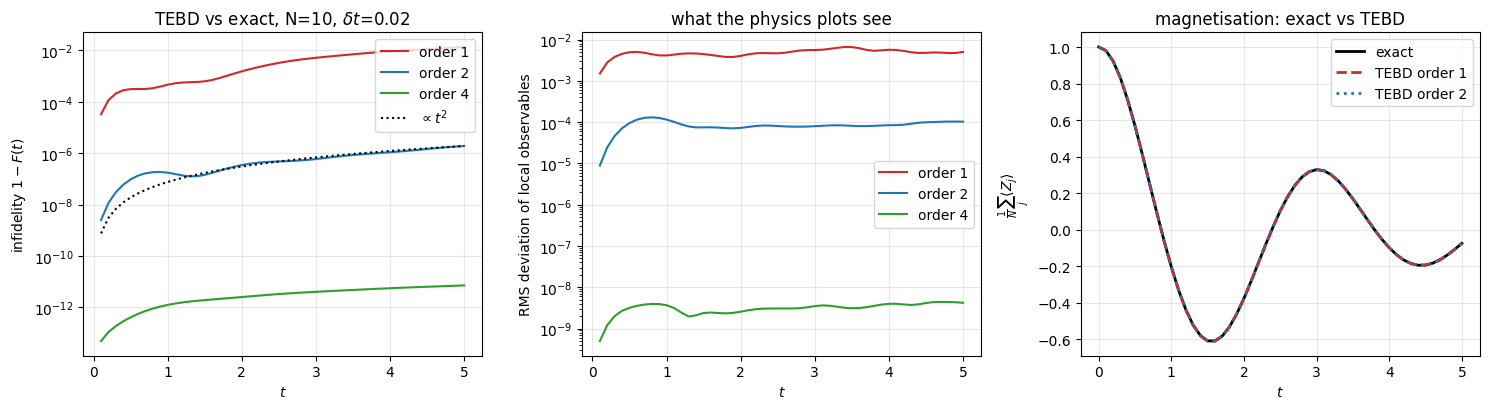

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
for order, c in zip((1, 2, 4), ("C3", "C0", "C2")):
    ax.semilogy(times[1:], np.maximum(check[order]["infid"][1:], 1e-16), color=c, label=f"order {order}")
ref = check[2]["infid"][-1] * (times[1:] / times[-1]) ** 2
ax.semilogy(times[1:], ref, "k:", label=r"$\propto t^2$")
ax.set_xlabel("$t$"); ax.set_ylabel(r"infidelity $1-F(t)$"); ax.set_title(f"TEBD vs exact, N={N_CHECK}, $\\delta t$={DT}")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for order, c in zip((1, 2, 4), ("C3", "C0", "C2")):
    ax.semilogy(times[1:], np.maximum(check[order]["rmse"][1:], 1e-16), color=c, label=f"order {order}")
ax.set_xlabel("$t$"); ax.set_ylabel("RMS deviation of local observables"); ax.set_title("what the physics plots see")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
mz_exact = np.asarray(obs_exact["bloch"][:, :, 2]).mean(1)
ax.plot(times, mz_exact, "k-", lw=2, label="exact")
for order, c, ls in zip((1, 2), ("C3", "C0"), ("--", ":")):
    ax.plot(times, np.asarray(check[order]["obs"]["bloch"][:, :, 2]).mean(1), color=c, ls=ls, lw=2, label=f"TEBD order {order}")
ax.set_xlabel("$t$"); ax.set_ylabel(r"$\frac{1}{N}\sum_j\langle Z_j\rangle$"); ax.set_title("magnetisation: exact vs TEBD")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the result.** (Numbers refer to the printed table.)

* The infidelity rises steeply at first and then much more slowly. The textbook estimate — per-step errors adding up *coherently*, $\epsilon(t)\sim C\,t\,\delta t^{\,p}$, hence $1-F\propto t^2$ (dotted guide) —
  is followed by the second-order curve from $t\approx1.5$ on, but for orders 1 and 4 it is a (safe) *upper bound*: once the state is spread over many eigenstates the errors of successive steps partly cancel.
  Never assume the nominal law; measure it.
* At the same $\delta t$ the first-order scheme — the one a simple hardware circuit implements — loses a visible fraction of the fidelity by $T=5$ ($1-F\approx10^{-2}$), while order 2 costs only twice the gates
  and is four orders of magnitude better; order 4 is essentially exact ($10^{-11}$) but costs $10\times$ the gates of order 1.
* **Local observables are far more forgiving than the fidelity**: on the right panel even the order-1 magnetisation is hard to tell from the exact curve by eye, and order 2 is indistinguishable —
  compare $1-F=1.4\times10^{-2}$ with an RMS observable error of $6.6\times10^{-3}$ for order 1. The fidelity compares $2^N$ amplitudes and
  decays with system size for any fixed local error; a local observable only feels the local error.

> **Numerical practice.** Choose $\delta t$ by the error *of the quantity you plot*, measured against a reference at small $N$, and remember that Trotter errors of local
> observables depend only weakly on $N$. From here on we use **order 2 with $\delta t=0.02$**.

### 4.1 Cross-checking the other integrators

The exact reference stops at $N\approx12$. For larger chains we need another *independent* high-accuracy method to validate TEBD against:
[Chebyshev propagation](13_chebyshev_propagation.ipynb) (polynomial expansion of $e^{-iHt}$, error down to round-off) and
[Krylov propagation](14_krylov_and_integrator_comparison.ipynb) (exponentiation in a small Lanczos subspace; we chain 25 steps of $\Delta t=0.2$ with subspace dimension 30).
First they have to pass the exact test themselves.

In [10]:
# ==============================================================================
# CHECKPOINT 2: Chebyshev and Krylov against the exact state at t = T (N = 10)
# ==============================================================================
bounds = spectral_bounds(terms, N_CHECK)
psi_cheb = chebyshev_evolve(psi0, terms, T_MAX, bounds)
psi_kry = psi0
for _ in range(25):                                   # 25 short Krylov steps: t * (spectral width) must stay <~ m
    psi_kry = krylov_evolve(psi_kry, terms, T_MAX / 25, m=30)

inf_cheb = 1.0 - float(fidelity_pure(traj_exact[-1], psi_cheb))
inf_kry = 1.0 - float(fidelity_pure(traj_exact[-1], psi_kry))
print(f"spectral bounds (Lanczos estimate): [{bounds[0]:.3f}, {bounds[1]:.3f}]")
print(f"Chebyshev : 1-F = {inf_cheb:.1e}")
print(f"Krylov    : 1-F = {inf_kry:.1e}")
print(f"TEBD-4    : 1-F = {check[4]['infid'][-1]:.1e}     TEBD-2: {check[2]['infid'][-1]:.1e}     TEBD-1: {check[1]['infid'][-1]:.1e}")
assert abs(inf_cheb) < 1e3 * TOL and abs(inf_kry) < 1e3 * TOL

spectral bounds (Lanczos estimate): [-15.178, 19.330]
Chebyshev : 1-F = -1.3e-15
Krylov    : 1-F = 4.4e-16
TEBD-4    : 1-F = 7.1e-12     TEBD-2: 1.9e-06     TEBD-1: 1.3e-02


Chebyshev and Krylov reproduce the exact state to (nearly) machine precision, so either can serve as the reference where dense algebra is impossible.
All five ways of computing $e^{-iHt}|\psi_0\rangle$ — dense diagonalisation, three Trotter orders, Chebyshev, Krylov — agree within their known error budgets.
We can now go to larger chains with a clear conscience.

## 5. Experiment 1 — relaxation after a quench of the XXZ chain in a transverse field

Same model and protocol, now at $N=14$ ($16\,384$ amplitudes; the dense Hamiltonian would already need 4 GB and a day of diagonalisation on a laptop — for us it is a few seconds).
We record the complete measurement set of §2.4. Since the exact reference is gone, the run is validated at the final time against Chebyshev propagation, and continuously by two
conservation laws: the norm (exactly conserved by every unitary gate) and the energy (conserved by the exact dynamics, but only approximately by a Trotter circuit — a built-in error monitor).

In [11]:
# ==============================================================================
# EXPERIMENT 1: PARAMETERS
# ==============================================================================
N1 = 14                                          # chain length (try 16: ~5x slower)
terms1 = heisenberg_terms(N1, JXX, JYY, JZZ, hx=HX)
gates1 = tebd_gates(terms1, DT, order=2)
bytes_per_amp = np.dtype(CDTYPE).itemsize                     # 16 bytes per amplitude in double precision, 8 in single
print(f"N = {N1}: state vector {2**N1} amplitudes = {2**N1 * bytes_per_amp / 1e6:.2f} MB ({CDTYPE.__name__}), "
      f"{len(gates1)} gates per 2nd-order step, {N_MEAS * N_SUB} steps")

run1 = jax.jit(lambda p: evolve_and_observe(p, gates1, N_MEAS, N_SUB, lambda s: observe_everything(s, p)))
psi0_1 = zero_state(N1)
t0 = time.time()
psiT_1, obs1 = run1(psi0_1)
jax.block_until_ready(obs1)
t_first = time.time() - t0
t0 = time.time()
psiT_1, obs1 = run1(psi0_1)
jax.block_until_ready(obs1)
t_second = time.time() - t0
print(f"first call (compile + run): {t_first:.1f} s | second call (run only): {t_second:.1f} s")

# ---- validation at the final time: TEBD vs Chebyshev (independent method, no Trotter error)
psi_ref = chebyshev_evolve(psi0_1, terms1, T_MAX, spectral_bounds(terms1, N1))
infid1 = 1.0 - float(fidelity_pure(psi_ref, psiT_1))
dev1 = float(jnp.max(jnp.abs(all_local_expectations(psi_ref) - obs1["bloch"][-1])))
print(f"TEBD-2 vs Chebyshev at T={T_MAX}: 1-F = {infid1:.2e},  max deviation of local <X>,<Y>,<Z> = {dev1:.2e}")
assert infid1 < 1e-2 and dev1 < 1e-2

# ---- energy from the recorded observables:  E = sum_bonds (Jxx<XX>+Jyy<YY>+Jzz<ZZ>) + hx sum_j <X_j>
E_t = (np.asarray(obs1["bonds"]) @ np.array([JXX, JYY, JZZ])).sum(1) + HX * np.asarray(obs1["bloch"][:, :, 0]).sum(1)
E0 = float(energy(terms1, psi0_1))
print(f"E(0) = {E_t[0]:.6f} (matrix-free <H>: {E0:.6f});  max_t |E(t)-E(0)| = {np.abs(E_t - E_t[0]).max():.2e};  "
      f"max_t | ||psi||-1 | = {np.abs(np.asarray(obs1['norm']) - 1).max():.1e}")
assert abs(E_t[0] - E0) < 1e3 * TOL and np.abs(np.asarray(obs1["norm"]) - 1).max() < 1e3 * TOL

N = 14: state vector 16384 amplitudes = 0.26 MB (complex128), 54 gates per 2nd-order step, 250 steps


first call (compile + run): 108.8 s | second call (run only): 113.1 s


TEBD-2 vs Chebyshev at T=5.0: 1-F = 2.95e-06,  max deviation of local <X>,<Y>,<Z> = 1.74e-04
E(0) = 6.500000 (matrix-free <H>: 6.500000);  max_t |E(t)-E(0)| = 3.34e-03;  max_t | ||psi||-1 | = 2.0e-12


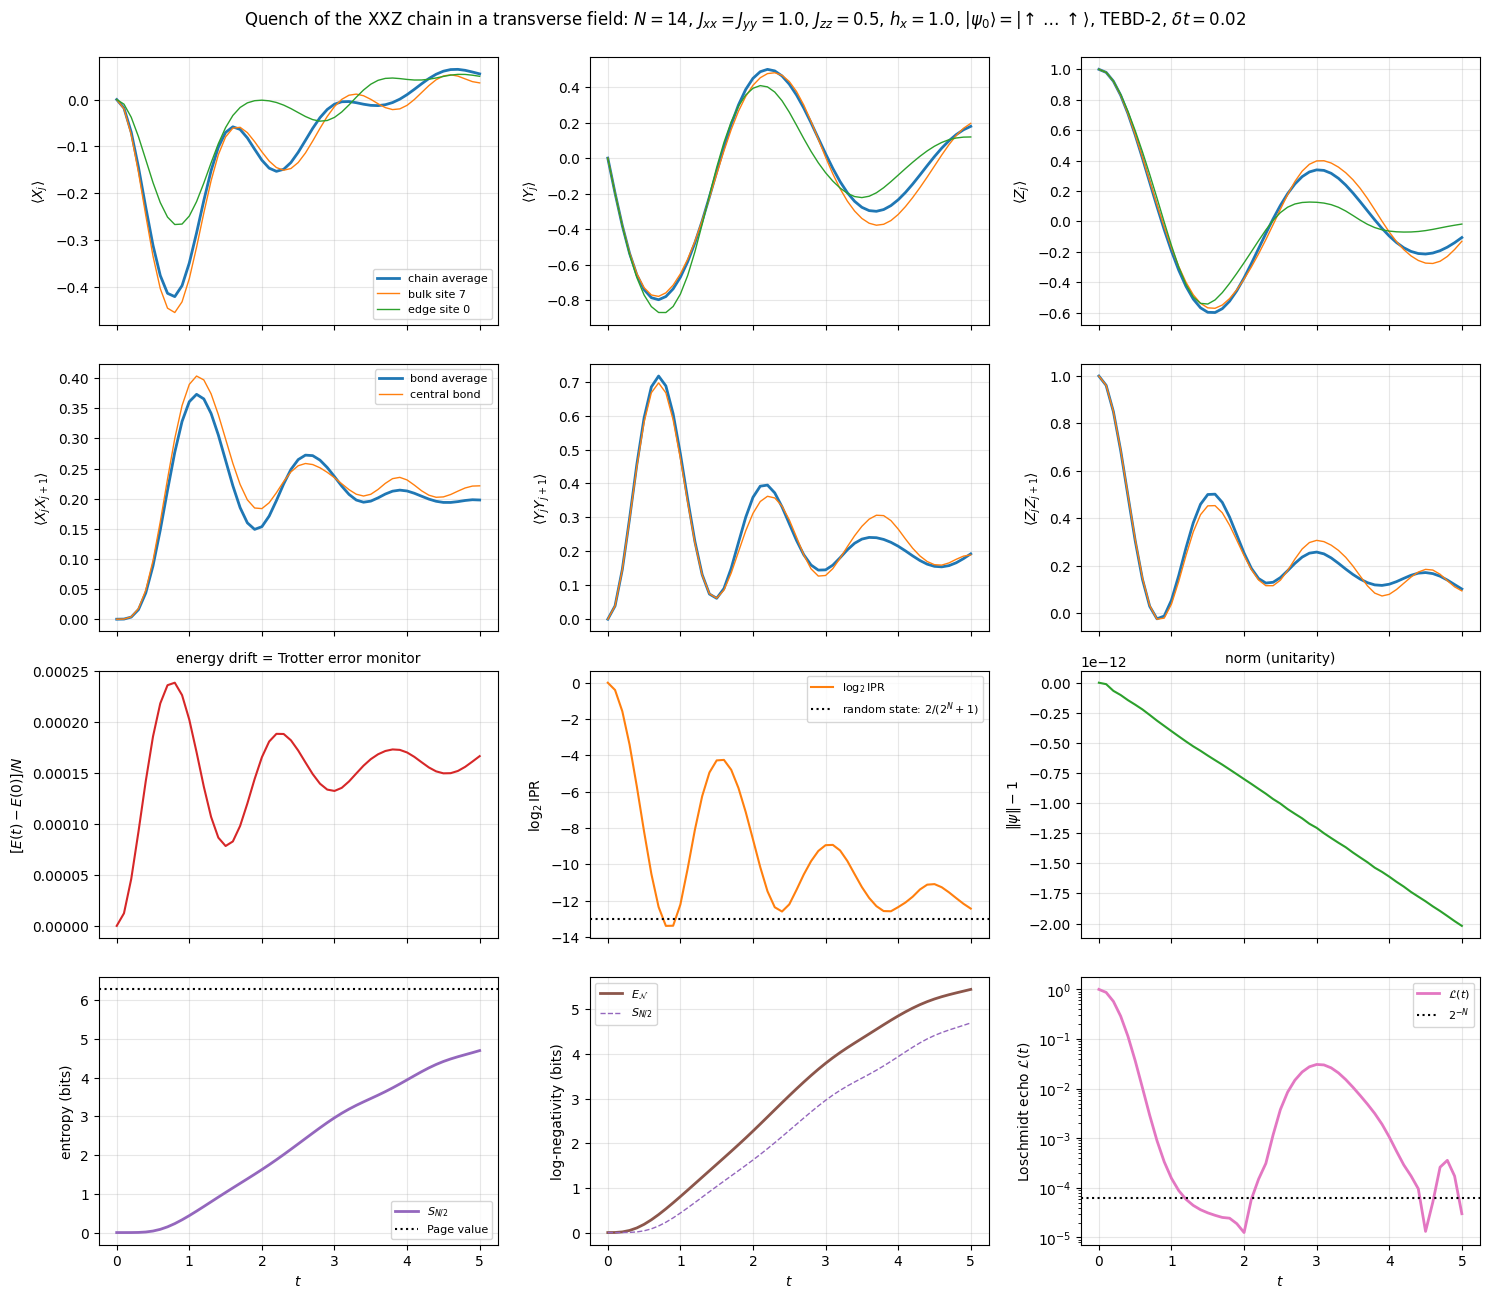

late-time (t>3) averages:  <Z> = -0.016,  <X> = +0.023,  <Y> = -0.107
S(T) = 4.70 bits (Page value 6.28),  E_N(T) = 5.45 bits,  log2 IPR(T) = -12.44 (random state -13.00),  min_t L = 1.3e-05


In [12]:
lam1 = obs1["schmidt"]
S1 = np.asarray(entropy_from_schmidt(lam1))
EN1 = np.asarray(jnp.log2(2 * negativity_from_schmidt(lam1) + 1))
page = N1 / 2 - 1 / (2 * np.log(2))                      # Page value (bits) for an equal bipartition of a random state

fig, axes = plt.subplots(4, 3, figsize=(15, 13), sharex=True)
bl, bd = np.asarray(obs1["bloch"]), np.asarray(obs1["bonds"])
for k, lab in enumerate(("X", "Y", "Z")):
    ax = axes[0, k]
    ax.plot(times, bl[:, :, k].mean(1), "C0", lw=2, label="chain average")
    ax.plot(times, bl[:, N1 // 2, k], "C1", lw=1, label=f"bulk site {N1 // 2}")
    ax.plot(times, bl[:, 0, k], "C2", lw=1, label="edge site 0")
    ax.set_ylabel(rf"$\langle {lab}_j\rangle$"); ax.grid(alpha=0.3)
    ax = axes[1, k]
    ax.plot(times, bd[:, :, k].mean(1), "C0", lw=2, label="bond average")
    ax.plot(times, bd[:, N1 // 2 - 1, k], "C1", lw=1, label="central bond")
    ax.set_ylabel(rf"$\langle {lab}_j {lab}_{{j+1}}\rangle$"); ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8); axes[1, 0].legend(fontsize=8)
ax = axes[2, 0]; ax.plot(times, (E_t - E_t[0]) / N1, "C3"); ax.set_ylabel(r"$[E(t)-E(0)]/N$"); ax.set_title("energy drift = Trotter error monitor", fontsize=10)
ax = axes[2, 1]; ax.plot(times, np.log2(np.asarray(obs1["ipr"])), "C1", label=r"$\log_2{\rm IPR}$")
ax.axhline(np.log2(2 / (2 ** N1 + 1)), color="k", ls=":", label=r"random state: $2/(2^N+1)$"); ax.set_ylabel(r"$\log_2 {\rm IPR}$"); ax.legend(fontsize=8)
ax = axes[2, 2]; ax.plot(times, np.asarray(obs1["norm"]) - 1, "C2"); ax.set_ylabel(r"$\|\psi\|-1$"); ax.set_title("norm (unitarity)", fontsize=10)
ax = axes[3, 0]; ax.plot(times, S1, "C4", lw=2, label=r"$S_{N/2}$"); ax.axhline(page, color="k", ls=":", label="Page value"); ax.set_ylabel("entropy (bits)"); ax.legend(fontsize=8)
ax = axes[3, 1]; ax.plot(times, EN1, "C5", lw=2, label=r"$E_{\mathcal{N}}$"); ax.plot(times, S1, "C4", lw=1, ls="--", label=r"$S_{N/2}$"); ax.set_ylabel("log-negativity (bits)"); ax.legend(fontsize=8)
ax = axes[3, 2]; ax.semilogy(times, np.asarray(obs1["echo"]), "C6", lw=2, label=r"$\mathcal{L}(t)$"); ax.axhline(2.0 ** (-N1), color="k", ls=":", label=r"$2^{-N}$")
ax.set_ylabel(r"Loschmidt echo $\mathcal{L}(t)$"); ax.legend(fontsize=8)
for ax in axes[2:].ravel():
    ax.grid(alpha=0.3)
for ax in axes[3]:
    ax.set_xlabel("$t$")
fig.suptitle(rf"Quench of the XXZ chain in a transverse field: $N={N1}$, $J_{{xx}}=J_{{yy}}={JXX}$, $J_{{zz}}={JZZ}$, $h_x={HX}$, "
             rf"$|\psi_0\rangle=|\!\uparrow\dots\uparrow\rangle$, TEBD-2, $\delta t={DT}$", y=0.995)
plt.tight_layout(); plt.show()

print(f"late-time (t>3) averages:  <Z> = {bl[times > 3][:, :, 2].mean():+.3f},  <X> = {bl[times > 3][:, :, 0].mean():+.3f},  <Y> = {bl[times > 3][:, :, 1].mean():+.3f}")
print(f"S(T) = {S1[-1]:.2f} bits (Page value {page:.2f}),  E_N(T) = {EN1[-1]:.2f} bits,  log2 IPR(T) = {np.log2(float(obs1['ipr'][-1])):.2f} "
      f"(random state {np.log2(2 / (2**N1 + 1)):.2f}),  min_t L = {float(obs1['echo'].min()):.1e}")

**Reading the twelve panels.**

* *Rows 1–2, local physics.* The initial magnetisation $\langle Z\rangle=1$ collapses on the time scale $t\sim1/J$ and then performs oscillations of clearly *decreasing* amplitude around a small value:
  the printed $t>3$ averages are $\langle Z\rangle=-0.02$, $\langle X\rangle=+0.02$, $\langle Y\rangle=-0.11$, while the curves themselves still swing by $\pm0.2$ at $T=5$ — relaxation by dephasing, Eq. (1),
  in a perfectly isolated, perfectly pure state, caught in the act rather than completed. The bond correlators (row 2) are already much closer to stationary. Bulk sites (orange) behave alike; the edge
  site (green) has only one neighbour and relaxes differently: open boundaries are visible.
* *Row 3, numerics.* The norm is conserved to round-off (unitary gates). The energy drifts by a small amount, consistent with the $O(\delta t^2)$ Trotter error — a free
  diagnostic that needs no reference solution. The final-time comparison with Chebyshev printed above confirms that observables are accurate to better than the line width.
* *Row 3, middle: delocalisation.* The IPR falls from 1 (a single basis state) by almost four orders of magnitude and then oscillates *around* the random-state value $2/(2^N+1)$ (dotted), dipping
  slightly below it at the first minimum: within a time $t\sim1$ the state is spread over essentially the whole computational basis. (The IPR is a crude measure — it says nothing about *which*
  states carry the weight, and energy conservation certainly restricts that.)
* *Row 4, entanglement.* The half-chain entropy grows roughly linearly from $t\approx0.7$ and has only just begun to bend over at $T=5$, at $4.7$ bits against the Page value $6.3$ of a random state:
  saturation is a later story (§8). The logarithmic negativity follows it from above ($E_{\mathcal N}\ge S$, they are the Rényi-$\tfrac12$ and Rényi-1 entropies of the same Schmidt spectrum).
  The Loschmidt echo decays to $\sim 2^{-N}$-ish values (minimum $1.3\times10^{-5}$ against $2^{-14}=6.1\times10^{-5}$), with a partial revival around $t=3$: the evolved state is nearly orthogonal to the initial one.

### 5.1 A sweep over initial states with `vmap`

Which stationary state is reached depends on the initial state only through its conserved quantities — here the energy. `evolve_and_observe` is a pure function of $\psi_0$,
so `jax.vmap` turns it into a function of a *batch* of initial states: one compilation, one call, five quenches. We take five product states with different energy densities
$e=\langle\psi_0|H|\psi_0\rangle/N$ and record entropy and echo ($N=12$ to keep the batch cheap).

> **JAX practice.** `jax.vmap(f)(batch)` adds a leading batch axis to every array inside `f` — the einsum strings of `apply_gate` are untouched, XLA simply
> sees one more index. The batch members need the same *shapes* (same $N$, same number of steps), but arbitrary *values*.

5 quenches, N=12, 250 steps each: 4.2 s (compile + run)


spectrum per site: [-1.527, +1.950]
  all up  |00..>           e = +0.458   S(T) = 4.17 bits   max_t S = 4.17
  Neel  |0101..>           e = -0.458   S(T) = 4.75 bits   max_t S = 4.79
  domain wall |0..01..1>   e = +0.375   S(T) = 4.40 bits   max_t S = 4.40
  all +y |rr..>            e = +0.917   S(T) = 2.78 bits   max_t S = 2.78
  all -x |--..>            e = -0.083   S(T) = 4.91 bits   max_t S = 4.91


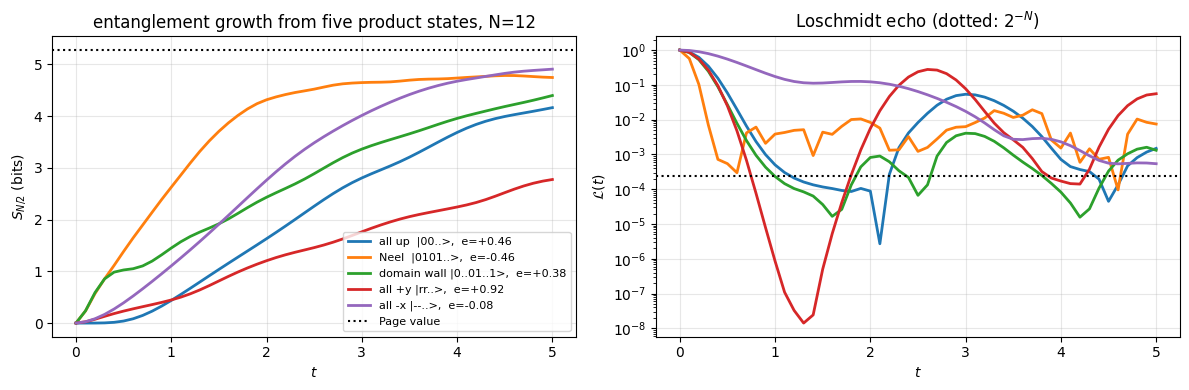

In [13]:
# ==============================================================================
# EXPERIMENT 1b: five initial product states in one vmapped call
# ==============================================================================
N1B = 12
specs = {"all up  |00..>": "0" * N1B,
         "Neel  |0101..>": "01" * (N1B // 2),
         "domain wall |0..01..1>": "0" * (N1B // 2) + "1" * (N1B // 2),
         "all +y |rr..>": "r" * N1B,
         "all -x |--..>": "-" * N1B}
batch = jnp.stack([product_state(s) for s in specs.values()])               # (5, 2,...,2)
terms1b = heisenberg_terms(N1B, JXX, JYY, JZZ, hx=HX)
gates1b = tebd_gates(terms1b, DT, order=2)


def run_from(psi_init):
    obs_fn = lambda s: dict(schmidt=half_chain_schmidt(s), echo=jnp.abs(jnp.vdot(psi_init, s)) ** 2)
    return evolve_and_observe(psi_init, gates1b, N_MEAS, N_SUB, obs_fn)[1]


t0 = time.time()
obs1b = jax.jit(jax.vmap(run_from))(batch)
jax.block_until_ready(obs1b)
print(f"5 quenches, N={N1B}, {N_MEAS * N_SUB} steps each: {time.time() - t0:.1f} s (compile + run)")

e_dens = np.array([float(energy(terms1b, p)) / N1B for p in batch])
w_lo, w_hi = spectral_bounds(terms1b, N1B)
S1b = np.asarray(entropy_from_schmidt(obs1b["schmidt"]))
print(f"spectrum per site: [{w_lo / N1B:+.3f}, {w_hi / N1B:+.3f}]")
for (name, _), e, s in zip(specs.items(), e_dens, S1b):
    print(f"  {name:24s} e = {e:+.3f}   S(T) = {s[-1]:.2f} bits   max_t S = {s.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (name, _), e, s, L in zip(specs.items(), e_dens, S1b, np.asarray(obs1b["echo"])):
    axes[0].plot(times, s, lw=2, label=f"{name},  e={e:+.2f}")
    axes[1].semilogy(times, np.maximum(L, 1e-12), lw=2)
axes[0].axhline(N1B / 2 - 1 / (2 * np.log(2)), color="k", ls=":", label="Page value")
axes[0].set_xlabel("$t$"); axes[0].set_ylabel(r"$S_{N/2}$ (bits)"); axes[0].set_title(f"entanglement growth from five product states, N={N1B}")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].axhline(2.0 ** (-N1B), color="k", ls=":"); axes[1].set_xlabel("$t$"); axes[1].set_ylabel(r"$\mathcal{L}(t)$")
axes[1].set_title("Loschmidt echo (dotted: $2^{-N}$)"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.** Every product state starts with $S=0$ and becomes entangled at a rate of order one bit per unit time, but the states differ in how far they get by $T=5$.

The organising quantity is the energy density $e$. Our $H$ is traceless, so $e=0$ is the centre of the spectrum, where the density of states is largest: the overwhelming majority of
eigenstates have energies near $e=0$, and their number falls off exponentially towards both spectral edges. The weights $|c_n|^2$ of Eq. (1) are conserved, so a state can spread only over
eigenstates near its own energy. A quench at $e=0$ has the most eigenstates available, and its half-chain entropy can approach the Page value of a random state; a state with $e\neq0$ has
exponentially fewer and is expected to stop below it.
The extremes follow that rule cleanly: $|{-}x\rangle^{\otimes N}$ ($e=-0.08$, essentially at the centre) climbs to $S=4.9$ bits, close to the Page value $5.3$, while $|{+}y\rangle^{\otimes N}$
($e=+0.92$, half-way to the upper spectral edge at $+1.95$, where the density of states is far lower) stops at $2.8$.
$|{-}x\rangle^{\otimes N}$ is the state the transverse field alone would favour, yet the bond terms push its energy back to the middle of the spectrum: you cannot guess $e$ from one term of $H$.

The three states in between do **not** order by $\lvert e\rvert$ alone, and the figure shows why: at $T=5$ only the Néel curve has flattened, the others are still climbing, so the ranking still
reflects the *growth rate* as much as the plateau. The Néel state ($e=-0.46$) has reached $4.75$ bits, the all-up state at the same $\lvert e\rvert$ ($e=+0.46$) only $4.17$, and the domain wall,
whose energy is closer to the centre ($e=+0.38$), sits between them at $4.40$. Deciding whether the *plateaux* follow the density of states needs runs long enough to saturate, which is what §8 does at a single
energy density. What the present data establish is the statement of §2.2 in its weak form: *the initial state enters the late-time physics through its conserved quantities*, and the energy density
alone already predicts the two extremes.

## 6. Experiment 2 — light cones: the spreading of correlations

### 6.1 Lieb–Robinson bounds

The Schrödinger equation is non-relativistic; nothing forbids, in principle, that flipping a spin at site 0 is felt instantly at site 100. Yet for lattice Hamiltonians with **short-range**
interactions Lieb and Robinson (1972) proved that there is an emergent maximal velocity: for local operators $A_x$, $B_y$,

$$\big\|[A_x(t),B_y]\big\|\;\le\;c\,\|A\|\,\|B\|\;e^{-(|x-y|-v_{\rm LR}t)/\xi},$$

(quoted without proof; $A_x(t)=e^{iHt}A_xe^{-iHt}$ and $\|\cdot\|$ is the operator norm). Outside the "light cone" $|x-y|=v_{\rm LR}t$ the influence is not strictly zero but *exponentially small*.
A corollary (Bravyi, Hastings, Verstraete 2006) concerns quenches from product states: connected correlations $C_{ij}(t)$ between two sites can only build up after the time $t\approx|i-j|/(2v)$ —
the factor 2 because *both* sites receive signals from a common source in between.

Two things about this theorem matter for what follows. First, it is an **existence statement**: it guarantees that *some* finite $v_{\rm LR}$ works, and the proof produces one — for a chain with
two-site terms $h_{j,j+1}$ the constant it produces is built from $\max_j\|h_{j,j+1}\|$ and is typically several times larger than the velocity one actually observes. It is an upper bound and a loose
one; it is not a prediction for where the front will be. Second, the quantity it bounds is the norm of a commutator — the worst case over all states — whereas we will measure a connected
correlation function in one particular state. The number that our data can be compared with is therefore **not** $v_{\rm LR}$ but the model-specific group velocity of the quasiparticles, which for
the Ising chain is known exactly and is the subject of the next subsection. The Lieb–Robinson bound explains why a light cone exists at all; the quasiparticle picture says where its edge is.

### 6.2 The quasiparticle picture

Calabrese and Cardy (2005–06) gave this an intuitive form. The quench injects energy everywhere; every point of the chain emits **pairs of entangled quasiparticles** with opposite momenta $\pm k$,
which then fly apart freely with the group velocity $v_k=d\varepsilon_k/dk$. Two sites at distance $r$ become correlated when they are hit by the two partners of a pair emitted half-way: $t=r/(2v_{\max})$.

For the transverse-field Ising chain $H=-J\sum_jZ_jZ_{j+1}-h\sum_jX_j$ the quasiparticles are exactly known free fermions (Pfeuty 1970; quoted without proof) with dispersion and maximal group velocity

$$\varepsilon_k=2\sqrt{J^2+h^2-2Jh\cos k},\qquad v_k=\frac{2Jh\sin k}{\sqrt{J^2+h^2-2Jh\cos k}},\qquad v_{\max}=2\min(J,h)$$

The last equality is worth deriving, because it is the only parameter-free number in this section. Write $c=\cos k$ and maximise $v_k^2=4J^2h^2(1-c^2)/(J^2+h^2-2Jhc)$ over $c$: the derivative
vanishes when $Jh\,c^2-(J^2+h^2)\,c+Jh=0$, whose two roots are $c=J/h$ and $c=h/J$. Exactly one of them lies in $[-1,1]$ — the ratio of the smaller coupling to the larger — and inserting it gives
$v_k^2=4\min(J,h)^2$. (For $J=h$ the two roots merge at $c=1$, i.e. the maximum sits at $k=0$, and $v_{\max}=2J$ again.) So

$$v_{\max}=2\min(J,h),\qquad\text{and the prediction to test is }\ \ r_{\rm front}(t)=2v_{\max}\,t=4\min(J,h)\,t\ \ \text{sites}.$$

The two factors of 2 have different origins and it is worth keeping them apart: the 2 in $\varepsilon_k$ is the Pauli convention of this course ($Z$ has eigenvalues $\pm1$, not $\pm\tfrac12$), while the
2 in $2v_{\max}$ is the *pair* mechanism — the correlation front moves at twice the speed of a single quasiparticle. A single-particle disturbance, such as one flipped spin, spreads at $v_{\max}$ only
(Exercise 3), and so does the magnetisation front of the domain wall in §7.

### 6.3 From formula to code

We quench from the ferromagnetic product state $|\!\uparrow\dots\uparrow\rangle$ (a ground state of $H$ at $h=0$) to $h=0.5$ and to the critical field $h=1$, and record the row $C_{cj}(t)$ of the connected
correlation matrix for a central site $c$. The two values of $h$ are handled by `vmap`: the gate list is built **inside** the traced function, so the matrix exponentials $e^{-ih_k\delta t}$ themselves depend on the traced $h$.

> **Common pitfall.** The engine's `heisenberg_terms` contains a Python `if hx != 0` — fine for concrete numbers, but a Python `if` cannot branch on a traced value. For a vmapped field we therefore build
> the (unconditional) term list ourselves.

In [14]:
# ==============================================================================
# EXPERIMENT 2: light cone in the transverse-field Ising chain
# ==============================================================================
def tfim_terms(N, J, h):
    """H = -J sum_j Z_j Z_j+1 - h sum_j X_j  as a list of local terms; `h` may be a traced scalar."""
    return [((j, j + 1), -J * ZZ) for j in range(N - 1)] + [((j,), -h * X) for j in range(N)]


# ---- PARAMETERS
N2, J2 = 14, 1.0
H_FIELDS2 = jnp.array([0.5, 1.0])              # post-quench fields (vmapped)
DT2, N_SUB2, N_MEAS2 = 0.02, 2, 80             # T = 3.2
C_SITE = N2 // 2 - 1                           # reference site c = 6
times2 = np.arange(N_MEAS2 + 1) * DT2 * N_SUB2


def run_lightcone(h):
    gates = tebd_gates(tfim_terms(N2, J2, h), DT2, order=2)       # exponentials of TRACED matrices
    obs_fn = lambda s: dict(corr=zz_connected_row(s, C_SITE), mz=z_profile(s))
    return evolve_and_observe(zero_state(N2), gates, N_MEAS2, N_SUB2, obs_fn)[1]


t0 = time.time()
obs2 = jax.jit(jax.vmap(run_lightcone))(H_FIELDS2)
jax.block_until_ready(obs2)
print(f"2 quenches, N={N2}, {N_MEAS2 * N_SUB2} steps: {time.time() - t0:.1f} s (compile + run)")

2 quenches, N=14, 160 steps: 5.6 s (compile + run)


front velocity = slope of a straight line through the arrival times of the distances r = 2..5
  (r = 1 is skipped: nearest neighbours are coupled directly; large r is skipped: the chain ends reflect)
 threshold |C| >     1e-02     1e-03     1e-04     1e-05     2 v_max
  h = 0.5: v_front      1.83      2.50      2.78      3.01         2.0
  h = 1.0: v_front      1.97      3.28      3.73      4.14         4.0


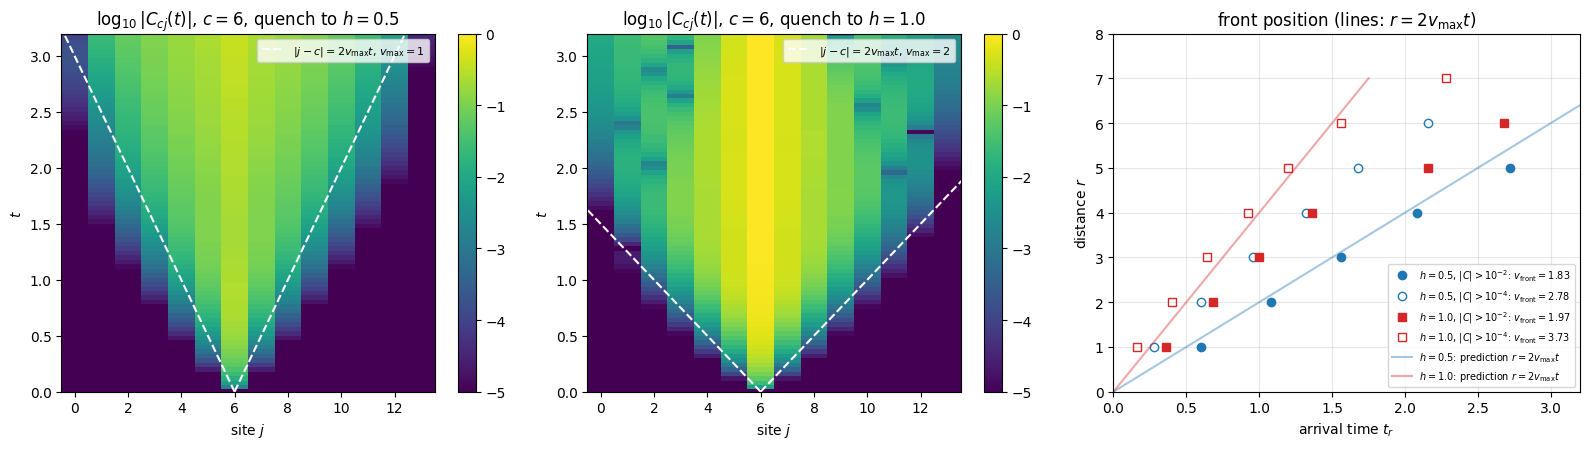

chain-averaged <Z> at t = 0, 1, 2, 3: {0.5: [1.0, 0.839, 0.808, 0.777], 1.0: [1.0, 0.284, 0.052, 0.004]}


In [15]:
corr2 = np.asarray(obs2["corr"])                       # (2, T, N)
THRESHOLDS = (1e-2, 1e-4)                              # "the correlation has arrived when |C_{c,c+r}| exceeds ..." (shown in the figure)
THRESHOLDS_ALL = (1e-2, 1e-3, 1e-4, 1e-5)              # the full scan, printed: the front velocity depends on this choice
R_FIT = N2 - C_SITE - 3                                # largest distance used in the fit: stay away from the chain end


def arrival_times(corr_h, thr):
    """First time |C_{c,c+r}(t)| exceeds `thr`, for every distance r >= 1.  Returns (r array, t array)."""
    rs, ts = [], []
    for dist in range(1, N2 - C_SITE):
        above = np.nonzero(np.abs(corr_h[:, C_SITE + dist]) > thr)[0]
        if len(above):
            rs.append(dist); ts.append(times2[above[0]])
    return np.array(rs), np.array(ts)


def front_velocity(corr_h, thr):
    """Slope of a straight line through the arrival times of the distances r = 2..R_FIT."""
    rs, ts = arrival_times(corr_h, thr)
    m = (rs >= 2) & (rs <= R_FIT)
    return np.polyfit(ts[m], rs[m], 1)[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
front = {}
for k, h in enumerate(np.asarray(H_FIELDS2)):
    ax = axes[k]
    data = np.log10(np.abs(corr2[k]) + 1e-12)
    im = ax.pcolormesh(np.arange(N2), times2, data, shading="nearest", cmap="viridis", vmin=-5, vmax=0)
    v = 2 * min(J2, h)
    r = np.arange(0, N2)
    ax.plot(C_SITE + r, r / (2 * v), "w--", lw=1.5, label=rf"$|j-c| = 2v_{{\max}}t$, $v_{{\max}}={v:.0f}$")
    ax.plot(C_SITE - r, r / (2 * v), "w--", lw=1.5)
    ax.set_xlim(-0.5, N2 - 0.5); ax.set_ylim(0, times2[-1])
    ax.set_xlabel("site $j$"); ax.set_ylabel("$t$"); ax.set_title(rf"$\log_{{10}}|C_{{cj}}(t)|$, $c={C_SITE}$, quench to $h={h}$")
    ax.legend(loc="upper right", fontsize=8); plt.colorbar(im, ax=ax)
    # arrival time of the correlation front at distance r: FIRST time |C| exceeds a threshold
    for thr in THRESHOLDS:
        front[(k, float(h), thr)] = arrival_times(corr2[k], thr)

ax = axes[2]
print(f"front velocity = slope of a straight line through the arrival times of the distances r = 2..{R_FIT}")
print("  (r = 1 is skipped: nearest neighbours are coupled directly; large r is skipped: the chain ends reflect)")
for (k, h, thr), (rs, ts) in front.items():
    col, mk = ("C0", "o") if h < 1.0 else ("C3", "s")
    slope = front_velocity(corr2[k], thr)
    ax.plot(ts, rs, mk, color=col, mfc=col if thr == THRESHOLDS[0] else "none",
            label=rf"$h={h}$, $|C|>10^{{{round(np.log10(thr)):d}}}$: $v_{{\rm front}}={slope:.2f}$")
print(f"{'threshold |C| >':>16} " + " ".join(f"{t:>9.0e}" for t in THRESHOLDS_ALL) + f"{'2 v_max':>12}")
for k, h in enumerate(np.asarray(H_FIELDS2)):
    print(f"  h = {h:.1f}: v_front " + " ".join(f"{front_velocity(corr2[k], thr):>9.2f}" for thr in THRESHOLDS_ALL)
          + f"{4 * min(J2, float(h)):>12.1f}")
for h in np.asarray(H_FIELDS2):
    rr = np.arange(0, N2 - C_SITE)
    ax.plot(rr / (4 * min(J2, float(h))), rr, "-", color="C0" if h < 1.0 else "C3", alpha=0.4,
            label=rf"$h={h}$: prediction $r=2v_{{\max}}t$")
ax.set_xlim(0, times2[-1]); ax.set_ylim(0, N2 - C_SITE)
ax.set_xlabel(r"arrival time $t_r$"); ax.set_ylabel("distance $r$")
ax.set_title("front position (lines: $r=2v_{\\max}t$)"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

mz2 = np.asarray(obs2["mz"]).mean(2)
print("chain-averaged <Z> at t = 0, 1, 2, 3:", {float(h): np.round(mz2[k][[0, 25, 50, 75]], 3).tolist() for k, h in enumerate(np.asarray(H_FIELDS2))})

**Interpretation.** On the logarithmic colour scale the light cone is unmistakable: at $t=0$ the product state has $C_{cj}=0$ for $j\ne c$ (the bright column at $j=c$ is just $C_{cc}=1-\langle Z_c\rangle^2$), and correlations
switch on site after site along a straight line. The arrival times in the right panel grow **linearly** with the distance $r$, and increasing $\min(J,h)$ opens the cone — that is the qualitative content of the
Lieb–Robinson bound and it is unambiguous. Outside the cone the correlations are not zero but tiny and decaying fast with distance — exactly the leakage that the bound permits.

The *numerical value* of the front velocity is a subtler matter, and it is worth dwelling on it because the same trap appears in every light-cone measurement, numerical or experimental. There is no sharp front:
at distance $r$ the correlation rises smoothly from the exponentially small Lieb–Robinson tail to an $\mathcal O(1)$ value, so "arrival" is whatever the threshold says it is. A **high** threshold declares the
arrival too late (velocity too small), a **low** one already triggers on the tail (velocity too large). The printed scan over four thresholds shows the bias directly, and it is *monotone* in the threshold:

* $h=0.5$ (prediction $2v_{\max}=2$): $1.83,\,2.50,\,2.78,\,3.01$ for $|C|>10^{-2},10^{-3},10^{-4},10^{-5}$ — the prediction is crossed between the first and the second threshold;
* $h=1$ (prediction $4$): $1.97,\,3.28,\,3.73,\,4.14$ — crossed between $10^{-4}$ and $10^{-5}$.

In both cases the measured velocity *brackets* the parameter-free quasiparticle prediction, which is as much as a chain of 14 sites can say: the systematic uncertainty of the front definition is tens of per
cent, far larger than the Trotter error. The bracketing happens at a lower threshold for $h=1$ because the front is much softer at criticality — the outer edge of the cone carries so little weight that a
$10^{-2}$ threshold registers only the slow, bright core. The white dashed lines in the colour maps say the same thing: at $h=0.5$ the prediction follows the outer edge of the bright region, at $h=1$ it runs
along the faintest visible edge. Reducing the uncertainty needs a longer chain, a threshold that follows the known decay of the signal with distance, or a fit to the whole space–time profile.

> **Common pitfall.** A front velocity read off a heat map is only as good as the contour you chose. Quote at least two thresholds, or quote the velocity with the bias it inherits — a single number
> agreeing with theory to three digits is a sign that the threshold was tuned, not that the physics was measured.

The time window is limited from above as well (§2.5): the reference site $c=6$ is 6 sites from the near end, so for $h=1$ the correlation front, moving at $2v_{\max}=4$, hits the end at $t\approx1.5$ and
comes back. This is why the fit stops at $r=5$, whose arrival time is $\approx1.25$; the data beyond $t\approx1.5$ in the colour maps are those of a box.

The printed magnetisation shows the second message of this quench: for $h=1$ (the critical field) the order parameter $\langle Z\rangle$ collapses from 1 to 0.004 within $t=3$, whereas for $h=0.5$ (inside the ferromagnetic phase) it is merely reduced to 0.78 — the quench does not destroy the order.

> **Physics insight.** This is the numerical twin of the experiment of Cheneau *et al.* (2012), who quenched a one-dimensional Bose gas in an optical lattice and watched two-point correlations appear at
> distance $r$ at times $\propto r$ in a quantum-gas microscope. With *long-range* interactions (trapped ions, $J_{ij}\sim1/|i-j|^\alpha$) the cone is no longer linear — see the exercises.

## 7. Experiment 3 — melting of a domain wall in the XXZ chain

### 7.1 Physics

Join a block of up spins to a block of down spins, $|\psi_0\rangle=|\!\uparrow\dots\uparrow\downarrow\dots\downarrow\rangle$, and evolve with the XXZ chain

$$H=J\sum_j\big(X_jX_{j+1}+Y_jY_{j+1}+\Delta\,Z_jZ_{j+1}\big).$$

$XX+YY=2(\sigma^+_j\sigma^-_{j+1}+{\rm h.c.})$ *hops* a flipped spin to the neighbouring site; the $\Delta$ term is an interaction between neighbouring flipped spins. The total magnetisation $\sum_jZ_j$ is conserved
(each bond gate commutes with $Z_j+Z_{j+1}$), so the only thing that can happen is **transport** of magnetisation across the wall — the spin-chain version of opening a valve between a full and an empty container.
This *inhomogeneous quench* is the standard probe of transport (Gobert *et al.* 2005; Ljubotina, Žnidarič, Prosen 2017), and the answer depends dramatically on $\Delta$:

* $\lvert\Delta\rvert<1$: **ballistic** — the wall melts into a front that expands linearly in time, and the transferred magnetisation grows $\propto t$;
* $\Delta=1$ (the isotropic Heisenberg point): **superdiffusive** — slower than ballistic but faster than diffusion. The transferred magnetisation grows as $t^{1/z}$ with the dynamical exponent
  $z=3/2$, i.e. $\propto t^{2/3}$, and the spin structure factor collapses onto the scaling function of the Kardar–Parisi–Zhang universality class (Ljubotina, Žnidarič, Prosen 2017, 2019);
* $\Delta>1$: the wall is essentially **frozen** — the domain-wall state is close to an eigenstate of the Ising-dominated Hamiltonian, and the transferred magnetisation saturates at an $\mathcal O(1)$ value.

The three regimes are statements about an *infinite* chain at *long* times. Our chain has 16 sites and the fastest front crosses it in $t=2$ (§2.5), so we can hope to see the ballistic case
quantitatively, the ordering of the three curves clearly, and nothing at all of the exponent $2/3$ — which the large-scale simulations above extract from chains of hundreds of sites and times $t\sim10^3$.

### 7.2 An exact benchmark at any $N$: free fermions

At $\Delta=0$ the chain is secretly non-interacting. The Jordan–Wigner transformation (Lieb, Schultz, Mattis 1961; quoted without proof) maps a down spin to a fermion, $n_j=(1-Z_j)/2$, and
$J(XX+YY)$ to a hopping Hamiltonian $\sum_{ij}h_{ij}c_i^\dagger c_j$ with the $N\times N$ matrix $h_{j,j+1}=h_{j+1,j}=2J$. Free fermions evolve independently: a particle starting on site $l$ has amplitude
$u_{jl}(t)=[e^{-iht}]_{jl}$ on site $j$, and the density is the sum over the initially occupied sites,

$$\langle Z_j(t)\rangle=1-2\sum_{l\in{\rm occ}}\big|[e^{-iht}]_{jl}\big|^2 .\qquad(3)$$

An $N\times N$ matrix instead of $2^N\times2^N$: this is what "integrable" buys you, and it gives us an **independent exact reference at sizes where dense diagonalisation is impossible**.
In the infinite chain the front moves with the maximal group velocity of $\varepsilon_k=4J\cos k$, i.e. $v_{\max}=\max_k\lvert d\varepsilon_k/dk\rvert=4J$ sites per unit time, and the magnetisation transferred
across the wall grows asymptotically as $4Jt/\pi$ (Antal *et al.* 1999). The front of a *melting wall* moves at $v_{\max}$, not at $2v_{\max}$ as the correlation front of §6: a domain wall is a single-particle
disturbance that the dynamics transports, not a source of entangled pairs whose two halves must both travel. Watching which of the two velocities a given observable picks up is the cleanest way to tell the
two mechanisms apart (Exercise 3).

### 7.3 Code: a `vmap` over the anisotropy $\Delta$

In [16]:
# ==============================================================================
# EXPERIMENT 3: domain-wall melting, vmapped over the anisotropy Delta
# ==============================================================================
def xxz_terms(N, J, delta):
    """H = J sum_j (XX + YY + delta ZZ); `delta` may be traced."""
    return [((j, j + 1), J * (XX + YY) + J * delta * ZZ) for j in range(N - 1)]


def domain_wall(N):
    """|up..up down..down> = |0..0 1..1>."""
    return basis_state([0] * (N // 2) + [1] * (N - N // 2))


def free_fermion_z_profile(N, J, occupied, ts):
    """Eq. (3): <Z_j(t)> of the XX chain (Delta = 0) from the N x N hopping matrix.  Returns (len(ts), N)."""
    h = np.zeros((N, N))
    for j in range(N - 1):
        h[j, j + 1] = h[j + 1, j] = 2.0 * J
    w, v = np.linalg.eigh(h)
    out = []
    for t in ts:
        U = (v * np.exp(-1j * w * t)) @ v.conj().T
        out.append(1.0 - 2.0 * (np.abs(U[:, occupied]) ** 2).sum(axis=1))
    return np.array(out)


# ---- PARAMETERS
N3, J3 = 16, 1.0
DELTAS = jnp.array([0.0, 0.5, 1.0, 2.0])
DT3, N_SUB3, N_MEAS3 = 0.02, 2, 60             # T = 2.4: the fastest front (4J) reaches the ends at t = 2
times3 = np.arange(N_MEAS3 + 1) * DT3 * N_SUB3


def run_domain_wall(delta):
    gates = tebd_gates(xxz_terms(N3, J3, delta), DT3, order=2)
    obs_fn = lambda s: dict(z=z_profile(s), schmidt=half_chain_schmidt(s))
    return evolve_and_observe(domain_wall(N3), gates, N_MEAS3, N_SUB3, obs_fn)[1]


t0 = time.time()
obs3 = jax.jit(jax.vmap(run_domain_wall))(DELTAS)
jax.block_until_ready(obs3)
print(f"4 quenches, N={N3} ({2**N3} amplitudes), {N_MEAS3 * N_SUB3} steps: {time.time() - t0:.1f} s (compile + run)")

# ---- CHECKPOINT 3: Delta = 0 against free fermions (exact for ANY N), and conservation of sum_j Z_j
z3 = np.asarray(obs3["z"])                              # (4, T, N)
z_ff = free_fermion_z_profile(N3, J3, list(range(N3 // 2, N3)), times3)
err_ff = np.abs(z3[0] - z_ff).max()
drift = np.abs(z3.sum(axis=2) - z3.sum(axis=2)[:, :1]).max()
print(f"max_(j,t) |<Z_j> TEBD - free fermions| at Delta=0 : {err_ff:.2e}   (Trotter error, O(dt^2))")
print(f"max_t |sum_j <Z_j>(t) - sum_j <Z_j>(0)| (all Delta) : {drift:.1e}   (exact symmetry of every gate)")
assert err_ff < 5e-3 and drift < 1e4 * TOL

4 quenches, N=16 (65536 amplitudes), 120 steps: 470.2 s (compile + run)
max_(j,t) |<Z_j> TEBD - free fermions| at Delta=0 : 6.24e-04   (Trotter error, O(dt^2))
max_t |sum_j <Z_j>(t) - sum_j <Z_j>(0)| (all Delta) : 1.1e-14   (exact symmetry of every gate)


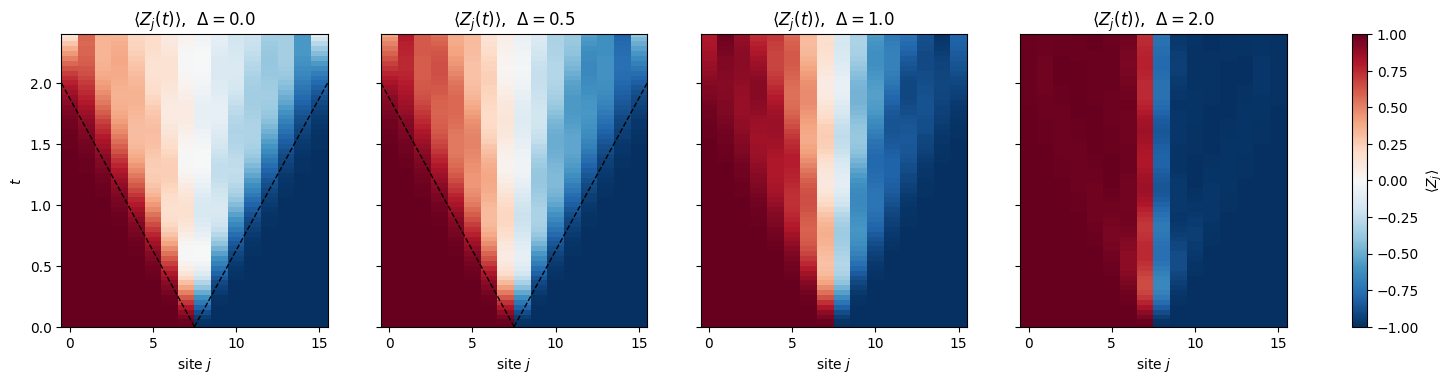

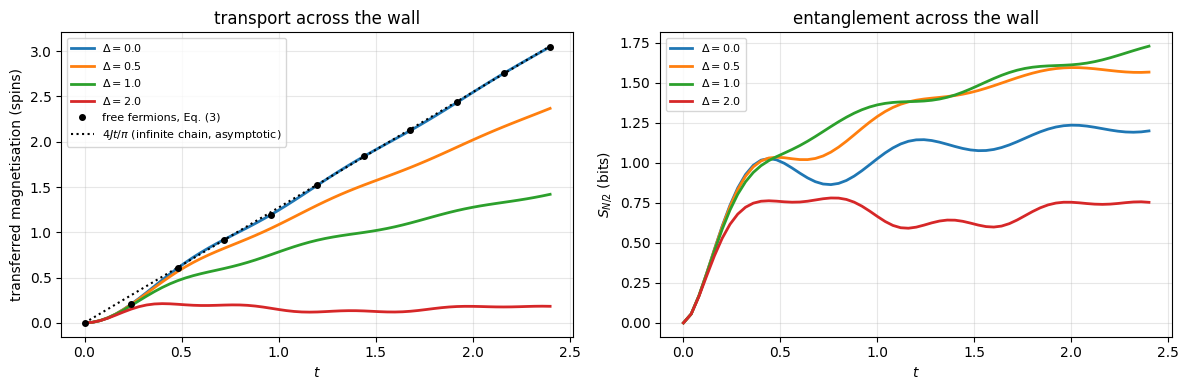

transferred magnetisation at t = 1.60: Delta=0.0: 2.029, Delta=0.5: 1.650, Delta=1.0: 1.061, Delta=2.0: 0.120   [4Jt/pi = 2.037]


In [17]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), sharey=True)
for k, d in enumerate(np.asarray(DELTAS)):
    im = axes[k].pcolormesh(np.arange(N3), times3, z3[k], shading="nearest", cmap="RdBu_r", vmin=-1, vmax=1)
    axes[k].set_title(rf"$\langle Z_j(t)\rangle$,  $\Delta={d}$"); axes[k].set_xlabel("site $j$")
    if d < 1:
        r = np.linspace(0, N3 / 2, 10)
        axes[k].plot(N3 / 2 - 0.5 + r, r / (4 * J3), "k--", lw=1); axes[k].plot(N3 / 2 - 0.5 - r, r / (4 * J3), "k--", lw=1)
    axes[k].set_ylim(0, times3[-1])
axes[0].set_ylabel("$t$")
plt.colorbar(im, ax=axes, label=r"$\langle Z_j\rangle$", fraction=0.02)
plt.show()

transferred = ((1.0 - z3[:, :, :N3 // 2]) / 2.0).sum(axis=2)       # number of down spins that crossed into the left half
S3 = np.asarray(entropy_from_schmidt(obs3["schmidt"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k, d in enumerate(np.asarray(DELTAS)):
    axes[0].plot(times3, transferred[k], lw=2, label=rf"$\Delta={d}$")
    axes[1].plot(times3, S3[k], lw=2, label=rf"$\Delta={d}$")
axes[0].plot(times3[::6], ((1.0 - z_ff[:, :N3 // 2]) / 2.0).sum(axis=1)[::6], "ko", ms=4, label="free fermions, Eq. (3)")
axes[0].plot(times3, 4 * J3 * times3 / np.pi, "k:", label=r"$4Jt/\pi$ (infinite chain, asymptotic)")
axes[0].set_xlabel("$t$"); axes[0].set_ylabel("transferred magnetisation (spins)"); axes[0].set_title("transport across the wall"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("$t$"); axes[1].set_ylabel(r"$S_{N/2}$ (bits)"); axes[1].set_title("entanglement across the wall"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
i1 = int(np.argmin(np.abs(times3 - 1.6)))
print(f"transferred magnetisation at t = {times3[i1]:.2f}: " + ", ".join(f"Delta={d}: {transferred[k][i1]:.3f}" for k, d in enumerate(np.asarray(DELTAS)))
      + f"   [4Jt/pi = {4 * J3 * times3[i1] / np.pi:.3f}]")

**Interpretation.**

* **Checkpoint.** At $\Delta=0$ the $2^{16}$-dimensional TEBD simulation reproduces the $16\times16$ free-fermion calculation up to the expected $O(\delta t^2)$ Trotter error, and $\sum_j\langle Z_j\rangle$ is conserved to round-off for all $\Delta$.
  A simulator that respects an exact solution *and* a symmetry it was never told about has earned some trust for the interacting cases, for which no such simple formula exists.
* **$\Delta<1$: ballistic melting.** The wall dissolves inside a cone bounded by the maximal velocity $4J$ (dashed), leaving behind a smooth profile; the transferred magnetisation grows linearly and follows $4Jt/\pi$ at $\Delta=0$.
  At $\Delta=0.5$ transport is still linear in time but slower. (Beyond $t=2$ the fastest front reaches the ends of our short chain.)
* **$\Delta=1$:** clearly slower than ballistic — the curve bends, and at $t=1.6$ it has transported $1.06$ spins against $2.03$ at $\Delta=0$. The asymptotic law $\propto t^{2/3}$ of Ljubotina *et al.* is
  *not* what we are seeing here: over one decade-free window of time, $t^{2/3}$ and, say, $t^{0.8}$ are indistinguishable, and the curve is still dominated by the initial rearrangement. All our data support
  is the ordering "slower than ballistic, faster than frozen".
* **$\Delta=2$: frozen.** After a quick rearrangement of the two spins next to the wall nothing moves: moving a spin across costs an energy $\sim J\Delta$ that the hopping $J$ cannot supply.
* **Entanglement.** At $\Delta=0$ the entropy across the wall shoots up to about one bit while the first particles cross and then barely moves (analytically it creeps up like $\tfrac16\ln t$ in nats,
  i.e. some $0.24$ bits per $e$-folding of the time — far too slowly to be visible in our window, where it is masked by the oscillations of the free-fermion front) —
  a free-particle front is a very "classical" object — whereas the interacting cases ($\Delta=0.5,1$) keep entangling the two halves and end up around $1.6$–$1.75$ bits. Note the ordering: at $t=2.4$ the $\Delta=1$ chain has transported the *least*
  magnetisation of the three mobile cases but generated the *most* entanglement. **Transport and entanglement are different things.**

## 8. Entanglement growth, integrable versus non-integrable dynamics, and why classical simulation dies

### 8.1 Linear growth and volume-law saturation

In the quasiparticle picture of §6.2 the half-chain entropy counts the pairs with one partner on each side of the cut. A pair emitted at distance $x$ from the cut contributes as soon as one of its partners has
crossed it, which happens at $t=x/v_k$. At time $t$ the contributing pairs are those emitted within a distance $v_kt$ of the cut, and their number grows **linearly** in $t$: the entropy grows linearly too, at a
rate given by the density of pairs weighted by their velocity and by the entropy $s(k)$ that each mode contributes,

$$\frac{dS}{dt}\;\propto\;\int\frac{dk}{2\pi}\,\lvert v_k\rvert\,s(k),\qquad s(k)=-n_k\log_2 n_k-(1-n_k)\log_2(1-n_k), \qquad (4)$$

with $n_k$ the occupation that the quench puts into mode $k$ (Calabrese & Cardy 2005; Alba & Calabrese 2017 turned this into an exact statement for integrable models). Eq. (4) is quoted, not derived; what we use of it is its structure. The growth stops when the pairs emitted at the far end of one half have reached the cut,

$$t_{\rm sat}\simeq\frac{N/2}{v_{\max}}=\frac{N}{2v_{\max}},$$

and then the entropy **saturates at a value proportional to the subsystem size** (a *volume law*):
$S_\infty\simeq s_\infty\,N/2$, with $s_\infty$ an entropy *per site* fixed by the quench energy and by what the dynamics conserves. Two cases matter here.

* A **chaotic** chain started at the centre of the spectrum ($e=0$) fills its half-chain Hilbert space as evenly as a random vector does, so $s_\infty=1$ bit per site up to the $O(1)$ correction computed by Page (1993):
  $S_{\rm Page}=N/2-\frac{1}{2\ln2}$ bits for an equal bipartition. This is an upper bound for every quench of this notebook — a state at $e\neq0$ saturates below it (§5.1).
* An **integrable** chain keeps its mode occupations $n_k$ for ever (each of them is conserved), and $s_\infty=\int\frac{dk}{2\pi}s(k)$ is the entropy of the occupations that the quench happens to produce.
  Unless $n_k=\tfrac12$ for every $k$, this is *less* than one bit per site: an integrable chain saturates below the Page value even when its energy lies exactly at the centre of the spectrum.
  We will measure both numbers.

### 8.2 Why this kills classical simulation

The Schmidt decomposition is the optimal way to compress a state across a cut: keeping $\chi$ terms requires $\chi\gtrsim2^{S}$ (for a flat Schmidt spectrum exactly $\chi=2^S$).
Matrix product states ([MPS-TEBD notebook](../ch07_tensor_networks/18_mps_tebd.ipynb)) store precisely such a truncated decomposition at every bond, with cost $\propto\chi^3$. Linear entropy growth therefore means

$$\chi(t)\sim2^{\,{\rm const}\cdot t}:\quad\text{the cost of a tensor-network simulation of a quench grows exponentially in time,}$$

while the full state vector costs $2^N$ from the start. Ground states (area law, $S={\rm const}$) are easy; quench dynamics is hard — and this is exactly the regime in which analog quantum simulators and quantum computers claim an advantage.

### 8.3 Integrable versus non-integrable: the tilted-field Ising chain

$$H=J\sum_jZ_jZ_{j+1}+g\sum_jX_j+h_z\sum_jZ_j,\qquad J=1,\ g=0.9045,\qquad h_z=\begin{cases}0&\text{integrable (TFIM, free fermions)}\\0.809&\text{non-integrable (parameters of Kim \& Huse 2013)}\end{cases}$$

The two chains differ by one term. At $h_z=0$ the longitudinal field is absent, the Jordan–Wigner transformation of §7.2 turns $H$ into free fermions, and the model has an extensive set of conserved mode
occupations. A longitudinal field maps to a string operator and destroys that structure: nothing is conserved beyond the energy, and the model is believed to be non-integrable — the usual numerical evidence
being the level-spacing statistics of the energy spectrum, which is Poissonian for an integrable model and Wigner–Dyson for a chaotic one (Atas *et al.* 2013). We take the classification as given here and
test its *consequences*; the level statistics of exactly these two chains is a natural exercise for the dense-diagonalisation code of notebook
[Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb). Both chains are evolved from the same state, with the same code, at the same energy: "integrable" and "non-integrable"
are properties of $H$ alone.

Initial state: all spins along $+y$. It has $\langle X\rangle=\langle Z\rangle=\langle Z_jZ_{j+1}\rangle=0$, hence $E=0={\rm Tr}H/2^N$: the centre of the spectrum, which is also the energy of the maximally mixed state $\mathbb 1/2^N$. If the local observables
relax to their values in that state, *every* traceless local observable must relax to $0$, and the entropy should approach the Page value — the value for the integrable chain being a different and more interesting question (§8.1).
We run both values of $h_z$ in one vmapped call for $N=8,10,12,14$ (a Python loop over $N$: different $N$ means different array shapes, which `vmap` cannot batch).

In [18]:
# ==============================================================================
# EXPERIMENT 4: entanglement growth and relaxation, integrable vs non-integrable
# ==============================================================================
def tilted_ising_terms(N, J, g, hz):
    """H = J sum ZZ + g sum X + hz sum Z; `hz` may be traced."""
    return [((j, j + 1), J * ZZ) for j in range(N - 1)] + [((j,), g * X + hz * Z) for j in range(N)]


# ---- PARAMETERS
J4, G4 = 1.0, 0.9045
HZ4 = jnp.array([0.0, 0.809])                  # integrable | non-integrable
SIZES4 = (8, 10, 12, 14)
DT4, N_SUB4, N_MEAS4 = 0.02, 8, 100            # T = 16, snapshot every 0.16
times4 = np.arange(N_MEAS4 + 1) * DT4 * N_SUB4


def make_run4(N):
    def run(hz):
        gates = tebd_gates(tilted_ising_terms(N, J4, G4, hz), DT4, order=2)
        obs_fn = lambda s: dict(schmidt=half_chain_schmidt(s), bloch_c=all_local_expectations(s)[N // 2])
        return evolve_and_observe(product_state("r" * N), gates, N_MEAS4, N_SUB4, obs_fn)
    return jax.jit(jax.vmap(run))


obs4, final4 = {}, {}
for N in SIZES4:
    t0 = time.time()
    final4[N], obs4[N] = make_run4(N)(HZ4)
    jax.block_until_ready(obs4[N])
    print(f"N = {N:2d}: 2 quenches x {N_MEAS4 * N_SUB4} steps in {time.time() - t0:5.1f} s (compile + run)")

# ---- CHECKPOINT 4: Trotter error of this long run (T=16) against the exact state at N=8
for k, hz in enumerate(np.asarray(HZ4)):
    ref = exact_trajectory(product_state("r" * 8), tilted_ising_terms(8, J4, G4, float(hz)), [times4[-1]])[0]
    print(f"   N=8, hz={hz}: 1-F(T={times4[-1]:.0f}) = {1 - float(fidelity_pure(ref, final4[8][k])):.2e}")

N =  8: 2 quenches x 800 steps in   1.5 s (compile + run)


N = 10: 2 quenches x 800 steps in   2.6 s (compile + run)


N = 12: 2 quenches x 800 steps in   5.6 s (compile + run)


N = 14: 2 quenches x 800 steps in 360.9 s (compile + run)


   N=8, hz=0.0: 1-F(T=16) = 1.60e-05


   N=8, hz=0.809: 1-F(T=16) = 1.21e-05


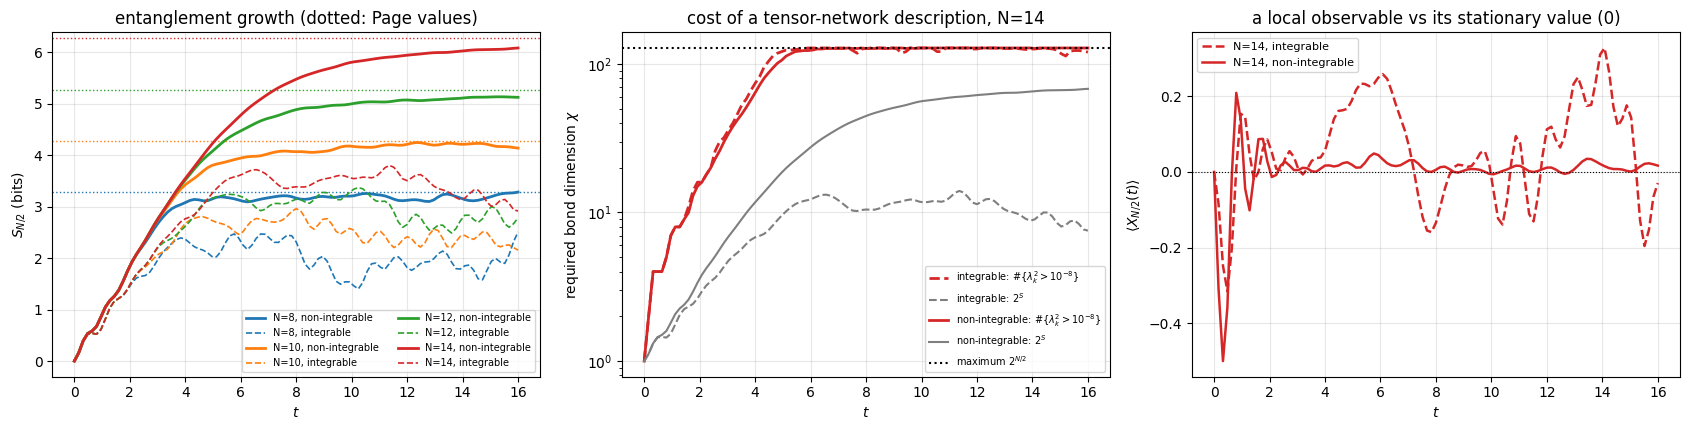

late-time window t > 8:   S/S_Page and plateau per site (bits)      <X_c>: mean +- temporal std
  N= 8   integrable: 0.57 (0.465/site)   non-integrable: 0.97 (0.797/site)      integrable: +0.028 +- 0.158    non-integrable: +0.029 +- 0.078
  N=10   integrable: 0.57 (0.486/site)   non-integrable: 0.98 (0.835/site)      integrable: +0.080 +- 0.149    non-integrable: +0.007 +- 0.022
  N=12   integrable: 0.55 (0.487/site)   non-integrable: 0.96 (0.842/site)      integrable: +0.041 +- 0.140    non-integrable: +0.014 +- 0.011
  N=14   integrable: 0.54 (0.488/site)   non-integrable: 0.94 (0.843/site)      integrable: +0.053 +- 0.127    non-integrable: +0.009 +- 0.010
entanglement velocity dS/dt in 1 < t < 4 (N=14, integrable): 0.68 bits per unit time
entanglement velocity dS/dt in 1 < t < 4 (N=14, non-integrable): 0.90 bits per unit time
v_max = 2 min(J,g) = 1.81 sites per unit time;  predicted saturation time N/(2 v_max) = 2.2 (N=8), 2.8 (N=10), 3.3 (N=12), 3.9 (N=14)
  N= 8: time to reach 90

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
cols = {8: "C0", 10: "C1", 12: "C2", 14: "C3"}
for N in SIZES4:
    S = np.asarray(entropy_from_schmidt(obs4[N]["schmidt"]))
    axes[0].plot(times4, S[1], color=cols[N], lw=2, label=f"N={N}, non-integrable")
    axes[0].plot(times4, S[0], color=cols[N], lw=1.2, ls="--", label=f"N={N}, integrable")
    axes[0].axhline(N / 2 - 1 / (2 * np.log(2)), color=cols[N], ls=":", lw=1)
axes[0].set_xlabel("$t$"); axes[0].set_ylabel(r"$S_{N/2}$ (bits)"); axes[0].set_title("entanglement growth (dotted: Page values)")
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3)

N = SIZES4[-1]
lam4 = np.asarray(obs4[N]["schmidt"])                                   # (2, T, 2^{N/2})
for k, (name, ls) in enumerate((("integrable", "--"), ("non-integrable", "-"))):
    chi = (lam4[k] ** 2 > 1e-8).sum(axis=1)
    axes[1].semilogy(times4, chi, "C3", ls=ls, lw=2, label=rf"{name}: #$\{{\lambda_k^2>10^{{-8}}\}}$")
    axes[1].semilogy(times4, 2.0 ** np.asarray(entropy_from_schmidt(obs4[N]["schmidt"]))[k], "C7", ls=ls, lw=1.5, label=rf"{name}: $2^S$")
axes[1].axhline(2 ** (N // 2), color="k", ls=":", label=r"maximum $2^{N/2}$")
axes[1].set_xlabel("$t$"); axes[1].set_ylabel(r"required bond dimension $\chi$"); axes[1].set_title(f"cost of a tensor-network description, N={N}")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

for k, (name, ls) in enumerate((("integrable", "--"), ("non-integrable", "-"))):
    axes[2].plot(times4, np.asarray(obs4[N]["bloch_c"])[k, :, 0], "C3", ls=ls, lw=1.8, label=f"N={N}, {name}")
axes[2].axhline(0, color="k", lw=0.8, ls=":")
axes[2].set_xlabel("$t$"); axes[2].set_ylabel(r"$\langle X_{N/2}(t)\rangle$"); axes[2].set_title("a local observable vs its stationary value (0)")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

late = times4 > 8.0
print("late-time window t > 8:   S/S_Page and plateau per site (bits)      <X_c>: mean +- temporal std")
for N in SIZES4:
    S = np.asarray(entropy_from_schmidt(obs4[N]["schmidt"]))
    xc = np.asarray(obs4[N]["bloch_c"])[:, :, 0]
    pg = N / 2 - 1 / (2 * np.log(2))
    print(f"  N={N:2d}   integrable: {S[0][late].mean() / pg:.2f} ({S[0][late].mean() / (N / 2):.3f}/site)   "
          f"non-integrable: {S[1][late].mean() / pg:.2f} ({S[1][late].mean() / (N / 2):.3f}/site)      "
          f"integrable: {xc[0][late].mean():+.3f} +- {xc[0][late].std():.3f}    non-integrable: {xc[1][late].mean():+.3f} +- {xc[1][late].std():.3f}")
# slope of the linear regime and the saturation time, for the largest N
S = np.asarray(entropy_from_schmidt(obs4[SIZES4[-1]]["schmidt"]))
win = (times4 > 1.0) & (times4 < 4.0)
v_max4 = 2 * min(J4, G4)                                  # maximal quasiparticle velocity of the hz = 0 chain
for k, name in enumerate(("integrable", "non-integrable")):
    print(f"entanglement velocity dS/dt in 1 < t < 4 (N={SIZES4[-1]}, {name}): {np.polyfit(times4[win], S[k][win], 1)[0]:.2f} bits per unit time")
print(f"v_max = 2 min(J,g) = {v_max4:.2f} sites per unit time;  predicted saturation time N/(2 v_max) = "
      + ", ".join(f"{N/(2*v_max4):.1f} (N={N})" for N in SIZES4))
for N in SIZES4:
    S = np.asarray(entropy_from_schmidt(obs4[N]["schmidt"]))
    t90 = [times4[np.argmax(S[k] >= 0.9 * S[k][late].mean())] for k in (0, 1)]
    print(f"  N={N:2d}: time to reach 90 % of the plateau -- integrable {t90[0]:.2f}, non-integrable {t90[1]:.2f}")

**Interpretation** (compare with the printed table).

* **Linear growth, then saturation $\propto N$.** For short times all system sizes share the *same* straight line — the cut does not yet know how long the chain is — and they peel off one by one and saturate at a height that grows with $N$: a volume law.
  The peel-off times printed under the figure follow the quasiparticle estimate $t_{\rm sat}=N/(2v_{\max})$ of §8.1 with $v_{\max}=2\min(J,g)=1.81$: the integrable chain reaches 90 % of its plateau at
  $t=2.7,\,3.5,\,4.2,\,4.8$ for $N=8,10,12,14$ against the predicted $2.2,\,2.8,\,3.3,\,3.9$ — the right slope in $N$, with the measured times some 25 % later because the last pairs to arrive travel
  slower than $v_{\max}$ and the crossover is gradual. The non-integrable chain takes longer still ($3.4,\,5.0,\,6.4,\,7.4$), because it has more entropy to accumulate at a comparable rate.
* **The slope is an entanglement velocity.** The measured slope in the window $1<t<4$ at $N=14$ is $0.90$ bits per unit time for the non-integrable chain and $0.68$ for the integrable one. A slope in
  bits per unit time becomes a velocity once it is divided by the entropy per site of the final ensemble, $dS/dt=s_\infty v_E$: it is the speed at which the maximally entangled region eats into the un-entangled one.
  For the non-integrable chain $s_\infty\approx1$ bit per site (the random-state value), so $v_E\approx0.90$ sites per unit time — **half** of $v_{\max}=1.81$ and a quarter of the correlation-front velocity
  $2v_{\max}=3.62$. ($v_{\max}=2\min(J,g)$ is exact only for the free chain $h_z=0$; for $h_z\neq0$ it is a velocity *scale* built from the same couplings, not a dispersion relation — the tilted chain has
  no free quasiparticles.) That entanglement spreads strictly more slowly than information is the generic situation, and it is the point of Kim & Huse (2013). For the integrable chain
  the bare slope is *smaller* ($0.68$) but so is the available entropy density ($s_\infty=0.49$ bits per site, next bullet), and the ratio $v_E=0.68/0.49=1.4$ sites per unit time is *larger*: free
  quasiparticles carry their entropy at their own group velocity, while in a chaotic chain the entropy has to be generated by scattering.
* **Non-integrable chain:** the plateau sits at 94–98 % of the Page value (dotted) at every size we can reach — for all local purposes the state is as entangled as a random vector. (The percentage does not *increase* with $N$ here only because
  the bigger chains need longer to saturate: the late-time window $t>8$ still catches part of the rise at $N=14$.) At the same time the local observable $\langle X_{N/2}\rangle$ relaxes to its
  stationary value $0$ (its value in the maximally mixed state), and the residual temporal fluctuations *shrink rapidly with $N$*: $0.078,\,0.022,\,0.011,\,0.010$ for $N=8,10,12,14$ (last columns of the table) — dephasing among exponentially many eigenstates, Eq. (1).
  The global state stays pure; a small subsystem looks featureless because it is entangled with the rest of the chain, which leaves its reduced density matrix close to maximally mixed.
* **Integrable chain:** the entropy saturates at only $\approx55\%$ of the Page value. That deficit is the point of §8.1: the plateau per site is $0.47,\,0.49,\,0.49,\,0.49$ bits for $N=8,10,12,14$ — an
  *intensive* number, and one that is clearly below the $1$ bit per site of a random state. The energy of this quench lies exactly at the centre of the spectrum ($E=0$), as for the non-integrable chain,
  which nearly reaches $\approx1$ bit per site ($0.80$ to $0.84$ bits per site, and still climbing at $T=16$). The free chain instead keeps the occupations $n_k$ that
  the quench produced, and Eq. (4) identifies the plateau with $s_\infty=\int\frac{dk}{2\pi}s(k)$: the measured $0.49$ bits per site is then the entropy of the **conserved** mode occupations, well
  below the random-state value at the same energy. (Confirming the identification requires the mode occupations of this particular initial state, which we do not compute here.) Consistently, $\langle X_{N/2}(t)\rangle$ keeps oscillating with an amplitude that barely shrinks with system size ($0.16\to0.13$ from $N=8$ to $N=14$, against a factor of eight for the
  non-integrable chain) — free quasiparticles never scatter, and in a finite chain they bounce between the ends and partially re-phase, exactly the revivals of §2.5.
* **The wall.** The middle panel translates entropy into cost. The *strict* count of non-negligible Schmidt values ($\lambda_k^2>10^{-8}$, red) grows exponentially in time and hits the maximum $2^{N/2}$ after $t\approx6$ for **both** chains —
  no Schmidt value is exactly zero any more. What distinguishes them is the *effective* bond dimension $2^{S}$ (grey), i.e. how many values actually carry weight: $\approx70$ for the non-integrable chain against $\approx8$ for the integrable one.
  A truncating tensor-network code lives off that second number, and for a generic quench it grows exponentially in time. For $N=14$ the maximum is a harmless 128, which is why we can afford the full state vector; for $N=100$ it would be $2^{50}$.
  Every classical method must give up at some $t$ or some $N$.

> **Numerical practice.** The checkpoint shows the price of a long evolution: after $T=16$ (800 steps at $\delta t=0.02$) the *fidelity* error of the Trotterised state has grown to $\approx1.5\times10^{-5}$ for both chains —
> still small, but two to three orders of magnitude above what the same scheme delivers over $T=5$ in §4, and growing. Local observables and entropies stay accurate. If you need the state itself at long times, use order 4 or Chebyshev/Krylov steps.

## 9. The Loschmidt echo and dynamical quantum phase transitions

### 9.1 Definition and short-time behaviour

The **Loschmidt amplitude** and **echo** (return probability)

$$G(t)=\langle\psi_0|e^{-iHt}|\psi_0\rangle=\sum_n|c_n|^2e^{-iE_nt},\qquad\mathcal L(t)=|G(t)|^2$$

ask how far the state has moved from where it started. $G(t)$ is the Fourier transform of the energy distribution $|c_n|^2$ of the initial state. Expanding the exponential to second order,
$G\simeq1-i\langle H\rangle t-\tfrac12\langle H^2\rangle t^2$, gives

$$\mathcal L(t)\simeq1-\sigma_E^2\,t^2,\qquad\sigma_E^2=\langle H^2\rangle-\langle H\rangle^2 .$$

For the TFIM quench from $|\!\uparrow\dots\uparrow\rangle$: $H|\psi_0\rangle=E_0|\psi_0\rangle-h\sum_j|\text{spin }j\text{ flipped}\rangle$, the $N$ flipped states are orthonormal and orthogonal to $|\psi_0\rangle$, hence $\sigma_E^2=Nh^2$:
the echo decays on the time scale $1/(h\sqrt N)$, and at later times it is exponentially small in $N$. The intensive quantity is the **rate function**

$$\lambda(t)=-\frac1N\ln\mathcal L(t).$$

### 9.2 Dynamical quantum phase transitions

Heyl, Polkovnikov and Kehrein (2013) showed that
$\lambda(t)$ of the TFIM becomes **non-analytic (kinks) at critical times** whenever the quench crosses the ground-state critical point $h_c=J$ — a *dynamical quantum phase transition* (DQPT). For a quench from $h_0=0$ to $h>J$
their free-fermion result (quoted without proof) gives

$$t_n=\Big(n+\tfrac12\Big)\,t^*,\qquad t^*=\frac{\pi}{\varepsilon_{k^*}}=\frac{\pi}{2\sqrt{h^2-J^2}},\qquad n=0,1,2,\dots$$

Our initial state $|\!\uparrow\dots\uparrow\rangle$ is one of **two** degenerate ground states at $h=0$. The appropriate return probability is then the one to the ground-state manifold,
$P(t)=P_\uparrow(t)+P_\downarrow(t)$ with $P_{\uparrow/\downarrow}=|\langle\uparrow\!..\!\uparrow/\downarrow\!..\!\downarrow|\psi(t)\rangle|^2$ (Heyl 2014). Both pieces are exponentially small in $N$, so for large $N$ the larger one wins completely:
$\lambda(t)=\min(\lambda_\uparrow,\lambda_\downarrow)$, and a **kink appears whenever the two branches cross** — the state switches from being "closer to all-up" to "closer to all-down". This is what was measured with 6–10 trapped ions by Jurcevic *et al.* (2017).

### 9.3 Code

$P_\uparrow$ and $P_\downarrow$ are just two amplitudes of the state tensor, `psi[0,0,...,0]` and `psi[1,1,...,1]`. We vmap over six post-quench fields.

In [20]:
# ==============================================================================
# EXPERIMENT 5: Loschmidt echo after TFIM quenches, vmapped over h
# ==============================================================================
N5, J5 = 14, 1.0
H_FIELDS5 = jnp.array([0.3, 0.6, 1.5, 2.0, 3.0])
DT5, N_SUB5, N_MEAS5 = 0.02, 1, 150            # T = 3, snapshot every step (fine grid: we want to locate kinks)
times5 = np.arange(N_MEAS5 + 1) * DT5 * N_SUB5


def run_echo(h):
    gates = tebd_gates(tfim_terms(N5, J5, h), DT5, order=2)
    obs_fn = lambda s: dict(p_up=jnp.abs(s[(0,) * N5]) ** 2, p_dn=jnp.abs(s[(1,) * N5]) ** 2, mz=jnp.mean(z_profile(s)))
    return evolve_and_observe(zero_state(N5), gates, N_MEAS5, N_SUB5, obs_fn)[1]


t0 = time.time()
obs5 = jax.jit(jax.vmap(run_echo))(H_FIELDS5)
jax.block_until_ready(obs5)
print(f"{len(H_FIELDS5)} quenches, N={N5}, {N_MEAS5 * N_SUB5} steps: {time.time() - t0:.1f} s (compile + run)")

# ---- CHECKPOINT 5: short-time expansion  L ~ 1 - sigma_E^2 t^2  with sigma_E^2 = N h^2
p_up = np.asarray(obs5["p_up"]); p_dn = np.asarray(obs5["p_dn"]); mz5 = np.asarray(obs5["mz"])
for k, h in enumerate(np.asarray(H_FIELDS5)):
    t_k = tfim_terms(N5, J5, float(h))
    Hpsi = apply_hamiltonian(t_k, zero_state(N5))
    var = float(jnp.real(jnp.vdot(Hpsi, Hpsi))) - float(energy(t_k, zero_state(N5))) ** 2       # matrix-free energy variance
    curv = (1 - p_up[k, 1]) / times5[1] ** 2
    print(f"  h = {h:.1f}: sigma_E^2 = {var:8.4f} (N h^2 = {N5 * h * h:8.4f}) | (1-L)/t^2 at t={times5[1]:.2f}: {curv:8.4f}")
    assert abs(var - N5 * h * h) < 1e4 * TOL and abs(curv / var - 1) < 0.05

5 quenches, N=14, 150 steps: 16.5 s (compile + run)
  h = 0.3: sigma_E^2 =   1.2600 (N h^2 =   1.2600) | (1-L)/t^2 at t=0.02:   1.2597


  h = 0.6: sigma_E^2 =   5.0400 (N h^2 =   5.0400) | (1-L)/t^2 at t=0.02:   5.0350


  h = 1.5: sigma_E^2 =  31.5000 (N h^2 =  31.5000) | (1-L)/t^2 at t=0.02:  31.3070
  h = 2.0: sigma_E^2 =  56.0000 (N h^2 =  56.0000) | (1-L)/t^2 at t=0.02:  55.3921
  h = 3.0: sigma_E^2 = 126.0000 (N h^2 = 126.0000) | (1-L)/t^2 at t=0.02: 122.9494


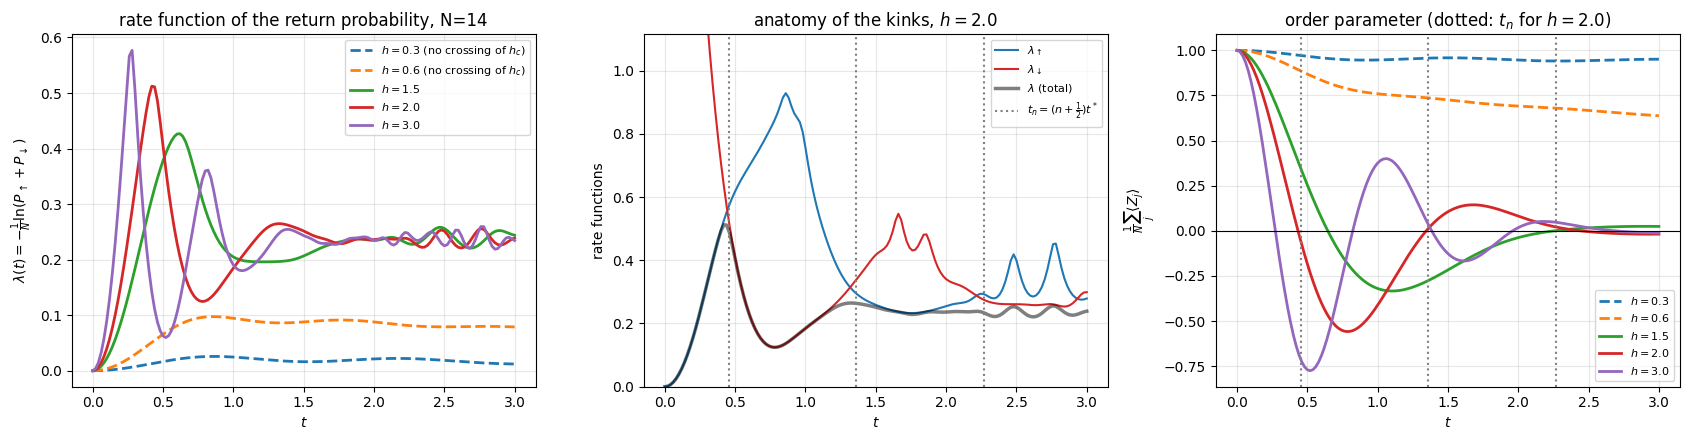

crossings of lambda_up and lambda_dn (linear interpolation) vs infinite-chain critical times t_n = (n+1/2) t*:
  h = 0.3: numerical []   predicted: none (quench inside the ferromagnetic phase)
  h = 0.6: numerical []   predicted: none (quench inside the ferromagnetic phase)
  h = 1.5: numerical [0.664, 2.017]   predicted [0.702, 2.107]
  h = 2.0: numerical [0.444, 1.318, 2.216, 2.933]   predicted [0.453, 1.36, 2.267, 3.174]
  h = 3.0: numerical [0.276, 0.824, 1.371, 1.922, 2.515, 2.877, 2.914]   predicted [0.278, 0.833, 1.388, 1.944, 2.499, 3.054, 3.61]


In [21]:
eps = 1e-300
lam_up, lam_dn = -np.log(p_up + eps) / N5, -np.log(p_dn + eps) / N5
lam_tot = -np.log(p_up + p_dn + eps) / N5

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for k, h in enumerate(np.asarray(H_FIELDS5)):
    axes[0].plot(times5, lam_tot[k], lw=2, label=f"$h={h}$" + (" (no crossing of $h_c$)" if h < J5 else ""), ls="--" if h < J5 else "-")
axes[0].set_xlabel("$t$"); axes[0].set_ylabel(r"$\lambda(t)=-\frac{1}{N}\ln(P_\uparrow+P_\downarrow)$"); axes[0].set_title(f"rate function of the return probability, N={N5}")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

k2 = int(np.argmin(np.abs(np.asarray(H_FIELDS5) - 2.0)))
h2 = float(H_FIELDS5[k2])
t_star = np.pi / (2 * np.sqrt(h2 ** 2 - J5 ** 2))
axes[1].plot(times5, lam_up[k2], "C0", lw=1.5, label=r"$\lambda_\uparrow$")
axes[1].plot(times5[1:], lam_dn[k2][1:], "C3", lw=1.5, label=r"$\lambda_\downarrow$")
axes[1].plot(times5, lam_tot[k2], "k", lw=2.5, alpha=0.5, label=r"$\lambda$ (total)")
for n in range(3):
    axes[1].axvline((n + 0.5) * t_star, color="gray", ls=":", label=r"$t_n=(n+\frac{1}{2})t^*$" if n == 0 else None)
axes[1].set_ylim(0, 1.2 * lam_tot[k2].max() + 0.5); axes[1].set_xlabel("$t$"); axes[1].set_ylabel("rate functions")
axes[1].set_title(f"anatomy of the kinks, $h={h2}$"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

for k, h in enumerate(np.asarray(H_FIELDS5)):
    axes[2].plot(times5, mz5[k], lw=2, ls="--" if h < J5 else "-", label=f"$h={h}$")
for n in range(3):
    axes[2].axvline((n + 0.5) * t_star, color="gray", ls=":")
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_xlabel("$t$"); axes[2].set_ylabel(r"$\frac{1}{N}\sum_j\langle Z_j\rangle$"); axes[2].set_title(f"order parameter (dotted: $t_n$ for $h={h2}$)")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# crossing times of the two branches vs the analytic critical times
print("crossings of lambda_up and lambda_dn (linear interpolation) vs infinite-chain critical times t_n = (n+1/2) t*:")
for k, h in enumerate(np.asarray(H_FIELDS5)):
    d = lam_up[k][1:] - lam_dn[k][1:]
    idx = np.nonzero(np.sign(d[:-1]) != np.sign(d[1:]))[0]
    tc = [times5[1:][i] + (times5[1:][i + 1] - times5[1:][i]) * d[i] / (d[i] - d[i + 1]) for i in idx]
    if h > J5:
        ts_ = np.pi / (2 * np.sqrt(h * h - J5 * J5))
        pred = [(n + 0.5) * ts_ for n in range(len(tc))]
        print(f"  h = {h:.1f}: numerical {np.round(tc, 3).tolist()}   predicted {np.round(pred, 3).tolist()}")
    else:
        print(f"  h = {h:.1f}: numerical {np.round(tc, 3).tolist()}   predicted: none (quench inside the ferromagnetic phase)")

**Interpretation.**

* **Checkpoint.** The matrix-free energy variance equals $Nh^2$ to round-off, and the measured initial curvature of the echo agrees with it within the expected $O(t^2)$ correction.
* **Quenches inside the ferromagnetic phase** ($h<J$, dashed): $\lambda(t)$ is smooth and small, the magnetisation stays positive, and $P_\downarrow$ never competes with $P_\uparrow$ — no crossings.
* **Quenches across the critical point** ($h>J$): the rate function develops sharp cusps. The middle panel shows their anatomy: each cusp is a crossing of the two branches $\lambda_\uparrow,\lambda_\downarrow$, and the crossing times (printed) fall close to the
  critical times $t_n=(n+\frac12)t^*$ of the infinite chain. The agreement improves the further the quench goes beyond $h_c$: the first crossing is $0.7\,\%$ below the prediction at $h=3$, $2\,\%$ at $h=2$ and $5\,\%$ at $h=1.5$,
  because a quench close to the critical point has a long $t^*$ and therefore feels the finite chain more. Later crossings drift further (at $h=3$ the last two entries of the printed list are finite-size artefacts: the two branches
  touch and separate again instead of crossing cleanly).
* **What a finite chain can and cannot show.** Strictly speaking, *there is no dynamical phase transition at $N=14$*. Both $P_\uparrow(t)$ and $P_\downarrow(t)$ are finite sums of the form
  $\lvert\sum_n a_n e^{-iE_nt}\rvert^2$ with $2^N$ terms, hence entire functions of $t$; their sum is strictly positive except at isolated points, so $\lambda(t)=-\frac1N\ln(P_\uparrow+P_\downarrow)$ is
  real-analytic — it has no kinks, only rapid changes of slope. The exact relation between the total rate function and the two branches,
  $\lambda=\min(\lambda_\uparrow,\lambda_\downarrow)-\frac1N\ln(1+e^{-N\lvert\lambda_\uparrow-\lambda_\downarrow\rvert})$, shows exactly how the non-analyticity is built: the corner of the $\min$ is
  rounded over a width in $t$ of order $1/N$, and the rounding disappears only as $N\to\infty$. What the numerics *does*
  establish is that the crossing times converge quickly, so that a finite chain locates the critical times of the infinite one to a few per cent. The honest procedure is to extract them at several $N$ and
  extrapolate (Exercise 6), not to call the finite-$N$ curve non-analytic.
* **Order parameter.** The zeros of the magnetisation line up with the critical times (right panel, dotted lines for $h=2$): every DQPT is a moment at which the state is "equidistant" from the two symmetry-broken ground states. This correspondence is exact for
  the infinite chain in this quench and was the experimental signature used with trapped ions.

> **Physics insight.** A DQPT is a non-analyticity *in time*, not in a control parameter, and no local observable jumps at $t_n$. But the echo is measurable (it is the probability of finding the initial bit
> string when all qubits are read out), and it is a remarkably sensitive fingerprint of the ground-state phase diagram.

## 10. Performance: the cost of a quench

One second-order TEBD step applies $2(2N-1)$ gates (for a chain with fields), each an einsum touching all $2^N$ amplitudes:

$$\text{time per step}\;\propto\;N\,2^N,\qquad\text{memory}=2^N\times(\text{bytes per amplitude: }16\text{ in double, }8\text{ in single precision})\times(\text{a few work copies}).$$

We measure it, separating **compile time** (tracing + XLA compilation, paid once per shape) from **run time**, and always blocking until the asynchronous computation has really finished.
We also compare the compiled `lax.scan` loop against a Python loop around a jitted single step — the latter pays a dispatch overhead per step, which matters only at small $N$.

  N gates/step  state (MB)  compile (s)  scan: ms/step  python loop: ms/step  ns per gate per amplitude


  8         30       0.004         0.83           0.31                  0.35                      40.55


 10         38       0.016         0.95           1.19                  0.50                      30.53


 12         46       0.066         1.05           4.10                  3.08                      21.74


 14         54       0.262         1.07          15.38                 13.45                      17.39


 16         62       1.049         1.04          61.57                 74.97                      15.15


 18         70       4.194         1.50         145.49                102.54                       7.93


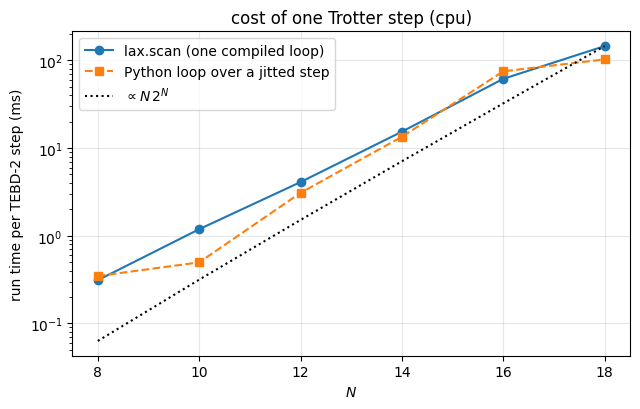

In [22]:
# ==============================================================================
# BENCHMARK: TEBD-2 steps of the XXZ + field chain versus N   (no observables)
# ==============================================================================
N_BENCH = (8, 10, 12, 14, 16, 18)             # 20 works too (16 MB state): expect several seconds per 20 steps on a laptop CPU
STEPS_BENCH = 20
print(f"{'N':>3} {'gates/step':>10} {'state (MB)':>11} {'compile (s)':>12} {'scan: ms/step':>14} {'python loop: ms/step':>21} {'ns per gate per amplitude':>26}")
bench = []
for N in N_BENCH:
    gates = tebd_gates(heisenberg_terms(N, JXX, JYY, JZZ, hx=HX), DT, order=2)
    p0 = zero_state(N)
    scan_run = jax.jit(lambda p, gates=gates: lax.scan(lambda s, _: (apply_gates(s, gates), None), p, None, length=STEPS_BENCH)[0])
    one_step = jax.jit(lambda p, gates=gates: apply_gates(p, gates))
    t0 = time.time(); scan_run(p0).block_until_ready(); t_first = time.time() - t0
    t0 = time.time(); scan_run(p0).block_until_ready(); t_run = time.time() - t0
    one_step(p0).block_until_ready()                    # compile the single step
    t0 = time.time()
    p = p0
    for _ in range(STEPS_BENCH):
        p = one_step(p)
    p.block_until_ready(); t_loop = time.time() - t0
    bench.append((N, t_run / STEPS_BENCH, t_loop / STEPS_BENCH, t_first - t_run))
    print(f"{N:>3} {len(gates):>10} {2**N * bytes_per_amp / 1e6:>11.3f} {t_first - t_run:>12.2f} {1e3 * t_run / STEPS_BENCH:>14.2f} {1e3 * t_loop / STEPS_BENCH:>21.2f} "
          f"{1e9 * t_run / STEPS_BENCH / len(gates) / 2**N:>26.2f}")

bench = np.array(bench)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.semilogy(bench[:, 0], 1e3 * bench[:, 1], "o-", label="lax.scan (one compiled loop)")
ax.semilogy(bench[:, 0], 1e3 * bench[:, 2], "s--", label="Python loop over a jitted step")
ref = bench[-1, 1] * (bench[:, 0] * 2.0 ** bench[:, 0]) / (bench[-1, 0] * 2.0 ** bench[-1, 0])
ax.semilogy(bench[:, 0], 1e3 * ref, "k:", label=r"$\propto N\,2^N$")
ax.set_xlabel("$N$"); ax.set_ylabel("run time per TEBD-2 step (ms)"); ax.set_title(f"cost of one Trotter step ({jax.default_backend()})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the benchmark** (absolute numbers depend on your machine and on what else it is doing; the structure does not).

* The two loop implementations come out close to each other here: on this CPU the Python → XLA dispatch that the explicit loop pays per step is already small compared with one TEBD step at $N=8$.
  The value of `scan` is that it compiles *once* (a 250-step Python loop under `jit` would be unrolled into 12 500 einsums) and that the whole quench, measurements included, becomes a single XLA program — not raw speed per step.
  On a GPU, or for much cheaper steps, the dispatch overhead does become visible.
* The growth with $N$ is close to, but a little shallower than, the $N\,2^N$ cost model (dotted line). The direction of the deviation is the expected one — bigger arrays use the vector units and the cache better —
  and it shows up in the last column, the time per gate per amplitude, which *falls* with $N$ instead of staying constant. Only the trends here are meaningful: these notes run on a shared CPU, and the absolute
  milliseconds (and single-digit factors) move from run to run. The exponential growth in $N$ is the robust part, and it is the part that matters.
* Compile time stays of the order of a second across the whole range, while the run time grows exponentially: compilation is set by the size of the **program** (the number of gates, $\propto N$), not by the
  size of the **data** ($2^N$), and it is paid once per chain length. Do not read the individual compile times as a clean trend — they are measured on a machine that is doing other things — but do read the
  fact that the *run* time crosses them somewhere around $N=14$ and leaves them far behind afterwards.
* Extrapolating with the cost model: $N=24$ ($\approx270$ MB state) costs roughly $100\times$ the $N=18$ step; $N\approx30$ is the practical end of the state-vector road on a workstation (16 GB per copy of the state). Beyond that, one needs
  either structure (low entanglement → [matrix product states](../ch07_tensor_networks/18_mps_tebd.ipynb)) or a quantum simulator.

> **JAX practice.** Everything in this notebook was compiled with a handful of `jax.jit` calls at the *outermost* level (a whole quench, including its measurements, is one XLA program) and parallelised over parameters by `jax.vmap`
> without touching the physics code. The price: shapes must be static (one compilation per $N$), and Python control flow must not depend on traced values (hence our own `tfim_terms`).

## 11. Summary — key takeaways

* A **quantum quench** — sudden change of $H$, then unitary evolution of a simple initial state — is the basic dynamical experiment of atoms in optical lattices, trapped ions, Rydberg arrays and superconducting qubits, and maps one-to-one onto "prepare, evolve, measure" in a simulator.
* **Relaxation in a closed system is dephasing** between exponentially many eigenstates, Eq. (1). In generic chains local observables relax to stationary values fixed essentially by the energy (entropy → Page value at the centre of the spectrum, fluctuations shrink with $N$); integrable chains remember more of the initial state.
* **Information has a speed limit.** The Lieb–Robinson theorem guarantees that some finite velocity bounds the spreading of commutators; it is an existence statement with a loose constant and it is *not*
  the number one measures. The measurable velocity is the quasiparticle one: correlations after a quench spread inside a light cone $r=2v_{\max}t$, with $v_{\max}=2\min(J,h)$ for the Ising chain and the
  factor 2 coming from the pair mechanism. Our data show the linear cone unambiguously, but the *numerical* front velocity depends on the threshold that defines "arrival" — high thresholds under-, low
  thresholds over-estimate it, and the prediction sits in between.
* **Transport depends on interactions**: a domain wall melts ballistically for $\lvert\Delta\rvert<1$, superdiffusively ($t^{2/3}$, KPZ) at the Heisenberg point, and is frozen for $\Delta>1$. At $\Delta=0$ an $N\times N$ free-fermion calculation provides an exact check at any size. Short chains show the ordering of the three regimes, not the exponent.
* **Entanglement grows linearly in time** after a quench, at a rate set by the velocity-weighted entropy of the excited modes, and saturates after $t\simeq N/(2v_{\max})$ at a volume law whose height is set by the
  quench energy and by what the dynamics conserves: the Page value for a chaotic chain at the centre of the spectrum, *less* for a state at $e\neq0$, and less again for an integrable chain, which saturates at the
  entropy of its conserved mode occupations ($0.49$ against $\approx1$ bit per site here). Since a tensor network needs bond dimension $\chi\sim2^S$, classical simulation cost grows exponentially in time — the reason quench dynamics is a prime application of quantum simulators.
* The **Loschmidt echo** decays as $1-Nh^2t^2$ at short times, is exponentially small in $N$ afterwards, and its rate function shows kinks (dynamical quantum phase transitions) at $t_n=(n+\tfrac12)t^*$ when the quench crosses the critical point.
  At finite $N$ the rate function is analytic: what the simulation shows is a corner rounded on the scale $1/N$, whose position converges rapidly to the critical times of the infinite chain.
* **Numerical habits**: validate against exact evolution at small $N$ and against an independent integrator at large $N$; monitor conserved quantities (norm, energy, magnetisation); judge the Trotter step by the error of the observable you need — the fidelity is much stricter than local observables.
* **JAX habits**: `scan` inside `scan` for evolve/measure loops, observables as a pytree, `vmap` over couplings (build the gates inside the traced function) and over initial states, `vmap` over time for reference trajectories, one `jit` around everything.

## 12. Exercises

1. ★ **Néel quench.** Repeat Experiment 1 from the Néel state $|\!\uparrow\downarrow\uparrow\downarrow\dots\rangle$ with $h_x=0$ (pure XXZ). Plot the staggered magnetisation $m_s(t)=\frac1N\sum_j(-1)^j\langle Z_j\rangle$ for $\Delta=J_{zz}/J_{xx}=0,\,0.5,\,1,\,2$ (use `vmap` as in §7).
   Check that $\sum_j\langle Z_j\rangle$ stays exactly zero (it is a symmetry of every gate). Run to $T=10$ and compare the late-time mean and standard deviation of $m_s$ for the four anisotropies:
   one of them relaxes far more smoothly than the others. Relate the two exceptions to (i) the free-fermion structure at $\Delta=0$ and (ii) the near-eigenstate character of the Néel state at $\Delta=2$,
   and repeat at $N=10$ to see how much of the late-time signal is a finite-size revival (§2.5).
2. ★ **Trotter budget.** In the checkpoint of §4 vary $\delta t\in\{0.01,0.02,0.04,0.08\}$ for order 2 and plot the final infidelity and the final RMS error of observables against $\delta t$ on log–log axes. Confirm the slopes 4 and 2. Then turn this into a cost comparison: for a target observable error, read off the $\delta t$ each order needs, multiply the number of steps $T/\delta t$ by the gates per step ($38$ and $190$ at $N=10$), and find the target error at which order 4 becomes the cheaper scheme.
3. ★★ **Light cone from a local quench.** Start the TFIM ($h=1$) from $|\!\uparrow\dots\uparrow\rangle$ with the central spin flipped, and plot $\langle Z_j(t)\rangle-\langle Z_j(t)\rangle_{\text{no flip}}$ as a heat map. The perturbation now travels at $v_{\max}$ rather than $2v_{\max}$ — explain why with the quasiparticle picture.
4. ★★ **Entanglement velocity.** Using the code of §8, extract $dS/dt$ in the linear regime of the non-integrable chain for several fields $g\in[0.5,1.5]$ (vmap over $g$ instead of $h_z$). How does the saturation time scale with $N$?
5. ★★ **Extend the code: long-range interactions.** Trapped ions realise $H=\sum_{i<j}\frac{J}{|i-j|^\alpha}Z_iZ_j+h\sum_jX_j$. Build the term list with all-to-all bonds (`apply_gate` does not care about distance), repeat the light-cone experiment of §6 for $\alpha=3$ and $\alpha=1$, and describe how the cone changes (cf. Richerme *et al.* 2014, Jurcevic *et al.* 2014). How does the number of gates per step scale with $N$ now?
6. ★★ **Finite-size scaling of the DQPT.** Repeat §9 for $N=8,10,12,14,16$ at $h=2$ and plot the first crossing time of $\lambda_\uparrow,\lambda_\downarrow$ against $1/N$. Does it extrapolate to $t^*/2$? Also plot $\lambda(t)$ near the first kink for all $N$ to see it sharpen.
7. ★★★ **Diagonal ensemble.** For $N=10$ compute the diagonal-ensemble prediction $\sum_n|c_n|^2O_{nn}$ of Eq. (1) for $O=X_{N/2}$ with dense diagonalisation (validation-style code), for both chains of §8, and compare with the late-time averages of the TEBD data. Then compare with $0$, the value in the maximally mixed state. Which chain relaxes to it?
8. ★★★ **Rényi-2 entropy as measured in experiments.** Islam *et al.* (2015) measured $S_2=-\log_2{\rm Tr}\rho_A^2$ by interfering two copies of the system. Add $S_2=-\log_2\sum_k\lambda_k^4$ to the post-processing of §8, compare its growth with $S$ and $E_{\mathcal N}$ (which is the Rényi-$\frac12$ entropy), and explain the ordering $S_{1/2}\ge S_1\ge S_2$.

## 13. References

**Reviews**

* A. Polkovnikov, K. Sengupta, A. Silva, M. Vengalattore, *Colloquium: Nonequilibrium dynamics of closed interacting quantum systems*, Rev. Mod. Phys. **83**, 863 (2011).
* F. H. L. Essler, M. Fagotti, *Quench dynamics and relaxation in isolated integrable quantum spin chains*, J. Stat. Mech. 064002 (2016).
* M. Heyl, *Dynamical quantum phase transitions: a review*, Rep. Prog. Phys. **81**, 054001 (2018).

**Light cones and entanglement growth**

* E. H. Lieb, D. W. Robinson, *The finite group velocity of quantum spin systems*, Commun. Math. Phys. **28**, 251 (1972).
* S. Bravyi, M. B. Hastings, F. Verstraete, *Lieb–Robinson bounds and the generation of correlations and topological quantum order*, Phys. Rev. Lett. **97**, 050401 (2006).
* P. Calabrese, J. Cardy, *Evolution of entanglement entropy in one-dimensional systems*, J. Stat. Mech. P04010 (2005); *Time dependence of correlation functions following a quantum quench*, Phys. Rev. Lett. **96**, 136801 (2006).
* V. Alba, P. Calabrese, *Entanglement and thermodynamics after a quantum quench in integrable systems*, Proc. Natl. Acad. Sci. USA **114**, 7947 (2017) — the quasiparticle formula, Eq. (4), made exact.
* H. Kim, D. A. Huse, *Ballistic spreading of entanglement in a diffusive nonintegrable system*, Phys. Rev. Lett. **111**, 127205 (2013) — the parameters of the non-integrable chain of §8 and the entanglement velocity.
* D. N. Page, *Average entropy of a subsystem*, Phys. Rev. Lett. **71**, 1291 (1993).
* G. Vidal, R. F. Werner, *Computable measure of entanglement*, Phys. Rev. A **65**, 032314 (2002).

**Integrability and level statistics**

* Y. Y. Atas, E. Bogomolny, O. Giraud, G. Roux, *Distribution of the ratio of consecutive level spacings in random matrix ensembles*, Phys. Rev. Lett. **110**, 084101 (2013).
* E. Lieb, T. Schultz, D. Mattis, *Two soluble models of an antiferromagnetic chain*, Ann. Phys. **16**, 407 (1961).
* P. Pfeuty, *The one-dimensional Ising model with a transverse field*, Ann. Phys. **57**, 79 (1970).

**Domain walls and transport**

* T. Antal, Z. Rácz, A. Rákos, G. M. Schütz, *Transport in the XX chain at zero temperature: Emergence of flat magnetization profiles*, Phys. Rev. E **59**, 4912 (1999).
* D. Gobert, C. Kollath, U. Schollwöck, G. Schütz, *Real-time dynamics in spin-1/2 chains with adaptive time-dependent density matrix renormalization group*, Phys. Rev. E **71**, 036102 (2005).
* M. Ljubotina, M. Žnidarič, T. Prosen, *Spin diffusion from an inhomogeneous quench in an integrable system*, Nat. Commun. **8**, 16117 (2017) — the domain-wall quench at $\Delta=1$ and the exponent $z=3/2$.
* M. Ljubotina, M. Žnidarič, T. Prosen, *Kardar–Parisi–Zhang physics in the quantum Heisenberg magnet*, Phys. Rev. Lett. **122**, 210602 (2019) — the KPZ scaling function.

**Loschmidt echo and dynamical quantum phase transitions**

* M. Heyl, A. Polkovnikov, S. Kehrein, *Dynamical quantum phase transitions in the transverse-field Ising model*, Phys. Rev. Lett. **110**, 135704 (2013).
* M. Heyl, *Dynamical quantum phase transitions in systems with broken-symmetry phases*, Phys. Rev. Lett. **113**, 205701 (2014).
* P. Jurcevic *et al.*, *Direct observation of dynamical quantum phase transitions in an interacting many-body system*, Phys. Rev. Lett. **119**, 080501 (2017).

**Experiments**

* T. Kinoshita, T. Wenger, D. S. Weiss, *A quantum Newton's cradle*, Nature **440**, 900 (2006).
* M. Cheneau *et al.*, *Light-cone-like spreading of correlations in a quantum many-body system*, Nature **481**, 484 (2012).
* P. Richerme *et al.*, *Non-local propagation of correlations in quantum systems with long-range interactions*, Nature **511**, 198 (2014);
  P. Jurcevic *et al.*, *Quasiparticle engineering and entanglement propagation in a quantum many-body system*, Nature **511**, 202 (2014).
* R. Islam, R. Ma, P. M. Preiss, M. E. Tai, A. Lukin, M. Rispoli, M. Greiner, *Measuring entanglement entropy in a quantum many-body system*, Nature **528**, 77 (2015).
* H. Bernien *et al.*, *Probing many-body dynamics on a 51-atom quantum simulator*, Nature **551**, 579 (2017).

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644) · [GitHub](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*.

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/